# RetailIQ Analytics Platform

## 01. Data Understanding

### Project Overview

RetailIQ is an end-to-end e-commerce analytics project built using the
Brazilian E-Commerce Public Dataset by Olist.

The objective of this phase is to understand the structure, quality,
relationships, and characteristics of the available datasets before
performing detailed analysis.

### Objectives of Data Understanding

In this phase, we will:

- Understand the available datasets and their business purpose.
- Inspect rows, columns, and data types.
- Identify primary and foreign key candidates.
- Analyze missing values.
- Check duplicate records.
- Investigate categorical variables.
- Understand relationships between customers and orders.
- Identify potential data-quality issues.
- Prepare date columns for further analysis.

> Important: No major data cleaning or deletion is performed in this
> phase. We first understand the data and investigate the reason behind
> potential issues.

## 1. Import Required Libraries

We use Pandas and NumPy for data loading, inspection, and analysis.

In [1237]:
import pandas as pd
import numpy as np

print("Environment is ready 🚀")


Environment is ready 🚀


## 2. Load the Datasets

The Olist dataset contains multiple CSV files representing different
parts of the e-commerce business.

The datasets will later be connected using common identifiers such as
`customer_id`, `order_id`, `product_id`, and `seller_id`.

In [1238]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
geo = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

## 3. Dataset Inspection Function

Instead of manually repeating the same inspection commands for every
dataset, we create a reusable function.

The function checks:

- Dataset shape
- Column names
- Data types
- Missing values
- Duplicate rows
- First few records

In [1239]:
def inspect(df, name):
    print("=" * 60)
    print(f"Dataset: {name}")
    print("=" * 60)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\nFirst Five Rows:")
    display(df.head())

In [1240]:
inspect(customers, "Customers")
inspect(orders, "Orders")
inspect(order_items, "Order Items")
inspect(products, "Products")
inspect(payments, "Payments")
inspect(reviews, "Reviews")
inspect(sellers, "Sellers")
inspect(geo, "Geolocation")
inspect(translation, "Category Translation")

Dataset: Customers

Shape:
(99441, 5)

Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Data Types:
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicate Rows:
0

First Five Rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Dataset: Orders

Shape:
(99441, 8)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Data Types:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicate Rows:
0

First Five Rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Dataset: Order Items

Shape:
(112650, 7)

Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Data Types:
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

Missing Values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Duplicate Rows:
0

First Five Rows:


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Dataset: Geolocation

Shape:
(1000163, 5)

Columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

Data Types:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str
dtype: object

Missing Values:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Duplicate Rows:
261831

First Five Rows:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Dataset: Category Translation

Shape:
(71, 2)

Columns:
['product_category_name', 'product_category_name_english']

Data Types:
product_category_name            str
product_category_name_english    str
dtype: object

Missing Values:
product_category_name            0
product_category_name_english    0
dtype: int64

Duplicate Rows:
0

First Five Rows:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


# 5. Customer Dataset

The customer dataset contains information about customers associated
with orders.

We will examine its structure, data quality, and customer identifiers.

In [1241]:
customers.shape

(99441, 5)

In [1242]:
customers.columns.tolist()

['customer_id',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [1243]:
customers.dtypes

customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

In [1244]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [1245]:
customers.duplicated().sum()

np.int64(0)

### Customer Dataset Findings

The customer dataset contains 99,441 records and 5 columns.
There are no missing values and no duplicate rows.
The dataset contains two customer identifiers:

- `customer_id`
- `customer_unique_id`

These identifiers have different purposes and must not be treated as
interchangeable.

## 5.1 Understanding Customer Identifiers

`customer_id` identifies a customer record in the Olist dataset.

`customer_unique_id` represents the underlying customer and can appear
multiple times across customer records.

This distinction is important for customer-level analysis such as:

- Repeat purchase analysis
- Customer retention
- RFM analysis
- Customer Lifetime Value
- Customer segmentation

In [1246]:
customers["customer_unique_id"].nunique()


96096

In [1247]:
customers["customer_id"].nunique()

99441

### Finding

The dataset contains:

- 99,441 unique `customer_id` values.
- 96,096 unique `customer_unique_id` values.

Therefore, multiple customer records can belong to the same underlying
customer.

This means `customer_unique_id` should be used when performing
customer-level behavioral analysis.

In [1248]:
customers["customer_unique_id"].value_counts().head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
dc813062e0fc23409cd255f7f53c7074     6
63cfc61cee11cbe306bff5857d00bfe4     6
f0e310a6839dce9de1638e0fe5ab282a     6
de34b16117594161a6a89c50b289d35a     6
Name: count, dtype: int64

In [1249]:
customers["customer_unique_id"].value_counts().value_counts()

count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
17        1
9         1
Name: count, dtype: int64

### Customer Record Distribution

Most underlying customers appear only once in the customer table,
while a smaller number appear multiple times.

This confirms that `customer_unique_id` is required for identifying
repeat customers correctly.

# 6. Orders Dataset

The orders dataset contains information about the lifecycle of each
order, including:

- Purchase time
- Approval time
- Carrier handover
- Customer delivery
- Estimated delivery
- Order status

This table will be one of the most important tables in our project.

In [1250]:
orders.shape

(99441, 8)

In [1251]:
orders.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

In [1252]:
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [1253]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [1254]:
orders.duplicated().sum()

np.int64(0)

## 6.1 Order Status Distribution

Before handling missing values, we investigate the distribution of
order statuses.

This helps us determine whether missing timestamps are legitimate
because an order may not have completed its lifecycle.

In [1255]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [1256]:
orders["order_status"].value_counts(normalize=True) * 100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

### Finding

Approximately 97% of orders have a `delivered` status.

The remaining orders are distributed across statuses such as
shipped, canceled, unavailable, invoiced, processing, created, and
approved.

The presence of incomplete order statuses is important when
interpreting missing delivery timestamps.

## 6.2 Investigating Missing Values

Missing values are not automatically treated as errors.

For example, an order that is still processing may naturally have no
customer delivery date.

Therefore, missing timestamps are compared against `order_status` to
determine whether the missingness is business-valid or potentially
anomalous.

In [1257]:
orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [1258]:
pd.crosstab(
    orders["order_status"],
    orders["order_delivered_customer_date"].isnull()
)

order_delivered_customer_date,False,True
order_status,,
approved,0,2
canceled,6,619
created,0,5
delivered,96470,8
invoiced,0,314
processing,0,301
shipped,0,1107
unavailable,0,609


order status in percentage

In [1259]:
pd.crosstab(
    orders["order_status"],
    orders["order_delivered_carrier_date"].isnull()
)

order_delivered_carrier_date,False,True
order_status,,
approved,0,2
canceled,75,550
created,0,5
delivered,96476,2
invoiced,0,314
processing,0,301
shipped,1107,0
unavailable,0,609


In [1260]:
pd.crosstab(
    orders["order_status"],
    orders["order_approved_at"].isnull()
)

order_approved_at,False,True
order_status,,
approved,2,0
canceled,484,141
created,0,5
delivered,96464,14
invoiced,314,0
processing,301,0
shipped,1107,0
unavailable,609,0


In [1261]:
# Carrier date missing vs status

pd.crosstab(
    orders["order_status"],
    orders["order_delivered_carrier_date"].isnull()
)

order_delivered_carrier_date,False,True
order_status,,
approved,0,2
canceled,75,550
created,0,5
delivered,96476,2
invoiced,0,314
processing,0,301
shipped,1107,0
unavailable,0,609


In [1262]:
pd.crosstab(
    orders["order_status"],
    orders["order_approved_at"].isnull()
)

order_approved_at,False,True
order_status,,
approved,2,0
canceled,484,141
created,0,5
delivered,96464,14
invoiced,314,0
processing,301,0
shipped,1107,0
unavailable,609,0


### Missing Value Investigation Findings

Most missing timestamps are logically associated with incomplete order
lifecycles.

For example:

- Shipped orders may not yet have a customer delivery date.
- Processing orders may not have a carrier date.
- Canceled orders may not have delivery information.

However, several exceptions were identified:

- 8 delivered orders have a missing customer delivery date.
- 14 delivered orders have a missing approval date.
- 2 delivered orders have a missing carrier date.
- 6 canceled orders contain a customer delivery date.

These records are treated as data-quality exceptions rather than being
automatically deleted.

We will retain them and handle them appropriately for specific
analyses.

## 6.3 Investigating Potential Data-Quality Anomalies

We inspect the actual records behind the unusual combinations
identified above.

if there is a missing values, so don't just delete them
insted:
 Missing Value
      ↓
Understand why it is missing
      ↓
Compare with business status
      ↓
Identify legitimate missingness
      ↓
Identify anomalies
      ↓
Decide treatment based on analysis

In [1263]:
# Delivered orders with missing delivery date

orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


In [1264]:
# Delivered orders with missing approval date
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_approved_at"].isnull())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17 00:00:00
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21 00:00:00
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17 00:00:00
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31 00:00:00
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20 00:00:00
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22 00:00:00
48401,7002a78c79c519ac54022d4f8a65e6e8,d5de688c321096d15508faae67a27051,delivered,2017-01-19 22:26:59,NaN,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16 00:00:00
61743,2eecb0d85f281280f79fa00f9cec1a95,a3d3c38e58b9d2dfb9207cab690b6310,delivered,2017-02-17 17:21:55,NaN,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20 00:00:00


In [1265]:
# Delivered orders with missing carrier date

orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_carrier_date"].isnull())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
73222,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaN,2017-11-20 19:44:47,2017-11-14 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00


In [1266]:
# Cancelled orders with a delivery date

orders[
    (orders["order_status"] == "canceled") &
    (orders["order_delivered_customer_date"].notnull())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
2921,1950d777989f6a877539f53795b4c3c3,1bccb206de9f0f25adc6871a1bcf77b2,canceled,2018-02-19 19:48:52,2018-02-19 20:56:05,2018-02-20 19:57:13,2018-03-21 22:03:51,2018-03-09 00:00:00
8791,dabf2b0e35b423f94618bf965fcb7514,5cdec0bb8cbdf53ffc8fdc212cd247c6,canceled,2016-10-09 00:56:52,2016-10-09 13:36:58,2016-10-13 13:36:59,2016-10-16 14:36:59,2016-11-30 00:00:00
58266,770d331c84e5b214bd9dc70a10b829d0,6c57e6119369185e575b36712766b0ef,canceled,2016-10-07 14:52:30,2016-10-07 15:07:10,2016-10-11 15:07:11,2016-10-14 15:07:11,2016-11-29 00:00:00
59332,8beb59392e21af5eb9547ae1a9938d06,bf609b5741f71697f65ce3852c5d2623,canceled,2016-10-08 20:17:50,2016-10-09 14:34:30,2016-10-14 22:45:26,2016-10-19 18:47:43,2016-11-30 00:00:00
92636,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25 00:00:00
94399,2c45c33d2f9cb8ff8b1c86cc28c11c30,de4caa97afa80c8eeac2ff4c8da5b72e,canceled,2016-10-09 15:39:56,2016-10-10 10:40:49,2016-10-14 10:40:50,2016-11-09 14:53:50,2016-12-08 00:00:00


In [1267]:

# convert into integer

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

### Data Quality Conclusion

The investigation shows that missing timestamps cannot be handled
using a simple `dropna()` strategy.

Most missing timestamps have a logical relationship with the order
status. A small number of inconsistent records were also identified.

Therefore:

- We will not blindly delete rows.
- We will not artificially fill missing timestamps.
- Missing timestamps will remain missing unless a specific analysis
  requires another treatment.
- Potential anomalies can be flagged for further investigation.

## 6.4 Converting Timestamp Columns

The order timestamp columns are initially stored as strings.

For time-based analysis, they need to be converted into Pandas
datetime objects.

This will allow us to calculate:

- Delivery duration
- Delivery delay
- Monthly trends
- Daily/weekly order trends
- Processing time

In [1268]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [1269]:
orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [1270]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


### Date Conversion Finding

The timestamp columns have successfully been converted from strings
to datetime objects.

Missing timestamps remain missing and were not artificially filled.

# 7. Delivery Performance Analysis

We now begin converting the raw order data into business metrics.

The first metric is delivery time.

### Delivery Time

Delivery time is calculated as:

Customer Delivery Timestamp - Order Purchase Timestamp

The metric is calculated only for orders where a customer delivery
timestamp is available.

In [1271]:
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

In [1272]:
orders["delivery_time_days"].describe()

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_time_days, dtype: float64

In [1273]:
orders[orders["delivery_time_days"] < 0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days


### Delivery Time Findings

The recorded delivery time has an average of approximately 12.56 days,
while the median is approximately 10 days.

The difference between the mean and median suggests that some orders
have unusually long delivery durations.

No negative delivery durations were identified, meaning no order was
recorded as being delivered before its purchase timestamp.

Extreme values should not automatically be removed because they may
represent genuine operational issues or data-quality problems.

In [1274]:
orders["delivery_time_days"].mean()

np.float64(12.558702304032053)

In [1275]:
orders["delivery_time_days"].median()

np.float64(10.21775462962963)

## 7.1 Creating the Delivered Orders Analysis Dataset

For delivery-performance KPIs, an order should be considered
"delivered" based on its `order_status`, rather than simply having a
delivery timestamp.

This prevents the small number of canceled orders that contain a
delivery timestamp from being incorrectly classified as delivered.

In [1276]:
delivered_orders = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].notna())
].copy()

In [1277]:
delivered_orders.shape

(96470, 9)

## 7.2 On-Time Delivery

An order is considered on-time when the actual customer delivery date
is on or before the estimated delivery date.

### Definition

On-Time = Actual Delivery Date <= Estimated Delivery Date

In [1278]:
delivered_orders["is_on_time"] = (
    delivered_orders["order_delivered_customer_date"]
    <= delivered_orders["order_estimated_delivery_date"]
)

In [1279]:
delivered_orders["is_on_time"].value_counts()

is_on_time
True     88644
False     7826
Name: count, dtype: int64

In [1280]:
delivered_orders["is_on_time"].value_counts(normalize=True) * 100

is_on_time
True     91.887633
False     8.112367
Name: proportion, dtype: float64

## 7.3 Delivery Delay

Delivery delay measures the difference between the actual delivery
date and the estimated delivery date.

### Formula

Delivery Delay =
Actual Delivery Date - Estimated Delivery Date

Interpretation:

- Negative value → Delivered early
- Zero → Delivered on the estimated date
- Positive value → Delivered late

In [1281]:
delivered_orders["delivery_delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

In [1282]:
delivered_orders["delivery_delay_days"].describe()

count    96470.000000
mean       -11.178126
std         10.184354
min       -146.016123
25%        -16.244065
50%        -11.948102
75%         -6.389815
max        188.975081
Name: delivery_delay_days, dtype: float64

### Delivery Delay Findings

The distribution of delivery delay contains both negative and positive
values.

Negative values indicate that orders were delivered earlier than the
estimated date, while positive values indicate late delivery.

The presence of extreme values indicates that delivery performance is
not uniform across all orders.

These extreme observations will be investigated further during
exploratory data analysis rather than being removed automatically.

# 8. Data Understanding Summary

## Customer Dataset

- 99,441 customer records are available.
- 96,096 unique underlying customers are represented.
- `customer_id` uniquely identifies customer records.
- `customer_unique_id` should be used for customer-level behavioral
  analysis.
- No missing values were found in the customer dataset.
- No duplicate rows were found.

## Orders Dataset

- 99,441 orders are available.
- `order_id` uniquely identifies orders.
- Approximately 97% of orders have a delivered status.
- Missing timestamps are mainly associated with incomplete order
  lifecycles.
- A small number of inconsistent records were identified.
- Timestamp columns were converted to datetime format.

## Delivery Analysis

- Average recorded delivery time is approximately 12.56 days.
- Median delivery time is approximately 10 days.
- No negative delivery durations were identified.
- Delivery delay contains both early and late deliveries.
- Extreme delivery durations exist and require further investigation.

## Data Handling Principle

Missing values and outliers are not automatically deleted.

Each issue is evaluated in the context of the underlying business
process before deciding how it should be handled.

# 9. Next Steps

The next phase of Data Understanding will examine the remaining
datasets:

1. Order Items
2. Products
3. Payments
4. Reviews
5. Sellers
6. Geolocation
7. Category Translation

After understanding all tables, we will establish the complete data
model and begin detailed data cleaning and exploratory analysis.

# 10. Order Items Dataset

The `order_items` dataset contains the individual products included
in each order.

While the Orders table contains one record per order, the Order Items
table can contain multiple records for a single order because an order
may contain multiple products.

This table will be essential for:

- Revenue analysis
- Product performance
- Seller performance
- Quantity analysis
- Average order value
- Product category analysis

In [1283]:
inspect(order_items, "Order Items")

Dataset: Order Items

Shape:
(112650, 7)

Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Data Types:
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

Missing Values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Duplicate Rows:
0

First Five Rows:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


## 10.1 Order Items Structure

The Order Items dataset contains 112,650 records and 7 columns.

Unlike the Orders dataset, where each row represents an order, each
row in the Order Items dataset represents a product item associated
with an order.

Therefore, a single order can have multiple rows in this table.

This creates a one-to-many relationship:

Orders → Order Items
1 → Many

In [1284]:
order_items["order_id"].nunique()

98666

In [1285]:
order_items["product_id"].nunique()

32951

In [1286]:
order_items["seller_id"].nunique()

3095

In [1287]:
#verifying the composite key( if output '0' then order_id + order_item_id uniquely identifies each row)

order_items[["order_id", "order_item_id"]].duplicated().sum()

np.int64(0)

In [1288]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

## 10.2 Order Items Data Quality and Relationships

The Order Items dataset contains 112,650 item-level records.

There are 98,666 unique orders represented in this table, compared
with 99,441 orders in the Orders dataset. This means that 775 orders
do not have corresponding order-item records and require further
investigation.

The dataset contains:

- 32,951 unique products.
- 3,095 unique sellers.
- No missing values.
- No duplicate rows.

The combination of `order_id` and `order_item_id` uniquely identifies
each order-item record, making it a composite key.

In [1289]:
#Which orders exist in Orders but don't exist in Order Items?
orders_without_items = orders[
    ~orders["order_id"].isin(order_items["order_id"])
].copy()

In [1290]:
orders_without_items.shape

(775, 9)

In [1291]:
orders_without_items["order_status"].value_counts()

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

### Orders Without Item Records

A total of 775 orders in the Orders dataset do not have a corresponding
record in the Order Items dataset.

The majority of these orders are associated with incomplete or
unsuccessful order lifecycles:

- 603 unavailable orders
- 164 canceled orders
- 5 created orders
- 2 invoiced orders
- 1 shipped order

These 775 orders represent approximately 0.78% of all orders.

The absence of item records is therefore largely associated with order
lifecycle status rather than widespread data corruption.

These records will be retained in the Orders dataset but will naturally
be excluded from item-level sales analysis where product-level
information is required.

In [1292]:
items_per_order = (
    order_items
    .groupby("order_id")
    .size()
)

In [1293]:
items_per_order.describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
dtype: float64

In [1294]:
# total items | no.of orders
items_per_order.value_counts().sort_index().head(10)

1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
9         3
10        8
Name: count, dtype: int64

## 10.3 Items per Order

To understand order composition, we calculate the number of item records
associated with each order.

### Findings

- 98,666 orders are represented in the Order Items dataset.
- The average order contains approximately 1.14 items.
- The median order contains 1 item.
- 88,863 orders, approximately 90.1%, contain exactly one item.
- Approximately 9.9% of orders contain multiple items.
- The maximum number of item records associated with a single order is
  21.

The distribution is highly concentrated around single-item orders.
This may be relevant for future basket-size, cross-selling, and product
bundling analysis.

In [1295]:
order_items["shipping_limit_date"].head()

0    2017-09-19 09:45:35
1    2017-05-03 11:05:13
2    2018-01-18 14:48:30
3    2018-08-15 10:10:18
4    2017-02-13 13:57:51
Name: shipping_limit_date, dtype: str

In [1296]:
order_items["shipping_limit_date"].isnull().sum()

c:\Users\ASUS\Desktop\RetailIQ-Analytics\.venv\Lib\site-packages\IPython\core\displayhook.py:291: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


np.int64(0)

In [1297]:
order_items["shipping_limit_date"].nunique()

93318

## 10.4 Order Items Summary

The Order Items dataset contains 112,650 item-level records across
98,666 unique orders.

Key findings:

- 32,951 unique products are represented.
- 3,095 unique sellers are represented.
- No missing values were identified.
- No duplicate rows were identified.
- `order_id` and `order_item_id` together form a unique composite key.
- Approximately 90.1% of orders represented in this table contain
  exactly one item.
- The average order contains approximately 1.14 items.
- The maximum number of items associated with an order is 21.
- 775 orders in the Orders dataset do not have corresponding item
  records. Most of these are unavailable or canceled orders.
- `shipping_limit_date` contains no missing values and is currently
  stored as a string.

The Order Items table will serve as a key transactional table for
future product, seller, revenue, and basket-size analysis.

# 11. Products Dataset

The Products dataset contains descriptive information about the
products sold through the marketplace.

We will examine:

- Product categories
- Product dimensions
- Product weight
- Number of product photos
- Missing values
- Duplicate records
- Product-level identifiers

This dataset will later be connected to the Order Items table through
`product_id`.

In [1298]:
inspect(products, "Products")

Dataset: Products

Shape:
(32951, 9)

Columns:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Data Types:
product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

Missing Values:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Duplicate Rows:
0

First Five Rows:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


## 11.1 Product Dataset Structure

The Products dataset contains 32,951 unique product records across
9 attributes.

The dataset provides descriptive information about products,
including category, dimensions, weight, description length, name
length, and number of product photos.

The `product_id` column is the product-level identifier and will later
be used to connect the Products dataset with the Order Items dataset.

No duplicate rows were identified, and `product_id` contains no
missing values.

However, 610 products have a missing `product_category_name`, which
requires further investigation.

In [1299]:
products["product_category_name"].isnull().sum()

np.int64(610)

In [1300]:
products[ products["product_category_name"].isnull()].head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
244,e10758160da97891c2fdcbc35f0f031d,NaN,NaN,NaN,NaN,2200.0,16.0,2.0,11.0
294,39e3b9b12cd0bf8ee681bbc1c130feb5,NaN,NaN,NaN,NaN,300.0,16.0,7.0,11.0
299,794de06c32a626a5692ff50e4985d36f,NaN,NaN,NaN,NaN,300.0,18.0,8.0,14.0
347,7af3e2da474486a3519b0cba9dea8ad9,NaN,NaN,NaN,NaN,200.0,22.0,14.0,14.0
428,629beb8e7317703dcc5f35b5463fd20e,NaN,NaN,NaN,NaN,1400.0,25.0,25.0,25.0


In [1301]:
products["product_id"].nunique()

32951

In [1302]:
products["product_id"].duplicated().sum()

np.int64(0)

In [1303]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [1304]:
products["product_category_name"].nunique()

73

In [1305]:
products["product_category_name"].value_counts().head(15)

product_category_name
cama_mesa_banho                3029
esporte_lazer                  2867
moveis_decoracao               2657
beleza_saude                   2444
utilidades_domesticas          2335
automotivo                     1900
informatica_acessorios         1639
brinquedos                     1411
relogios_presentes             1329
telefonia                      1134
bebes                           919
perfumaria                      868
papelaria                       849
fashion_bolsas_e_acessorios     849
cool_stuff                      789
Name: count, dtype: int64

## 11.2 Product Data Quality Findings

The Products dataset contains 32,951 unique products.

The `product_id` column contains no missing or duplicate values and
therefore uniquely identifies each product.

A total of 610 products have missing values in
`product_category_name`, `product_name_length`,
`product_description_length`, and `product_photos_qty`.

Only 2 products have missing physical attributes such as weight and
dimensions.

The dataset contains 73 known product categories. The most frequently
represented categories include bed, bath and table products,
sports/leisure, furniture/decor, health and beauty, and household
utilities.

The 610 missing-category records require further investigation to
determine whether the missing attributes occur in the same products.

In [1306]:
products[
    products["product_category_name"].isnull() &
    products["product_name_lenght"].notnull()
].shape

(0, 9)

In [1307]:
products[
    products["product_category_name"].isnull() &
    products["product_description_lenght"].notnull()
].shape

(0, 9)

In [1308]:
products[
    products["product_category_name"].isnull() &
    products["product_photos_qty"].notnull()
].shape

(0, 9)

In [1309]:
products[
    products["product_weight_g"].isnull()
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1310]:
products[
    products["product_length_cm"].isnull()
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1311]:
products[
    products["product_height_cm"].isnull()
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1312]:
products[
    products["product_width_cm"].isnull()
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 11.3 Investigating Missing Product Attributes

The missing-value analysis reveals that the 610 products with a missing
`product_category_name` also have missing values for
`product_name_lenght`, `product_description_lenght`, and
`product_photos_qty`.

This indicates that these missing values occur together rather than
being independent missing observations.

Two products also have missing physical attributes including weight
and dimensions. One of these products is also part of the 610 products
with missing descriptive information.

The missing records will be retained at this stage and investigated
further before deciding on any treatment.

In [1313]:
missing_category_products = products[
    products["product_category_name"].isnull()
].copy()

In [1314]:
missing_category_products["product_id"].isin(
    order_items["product_id"]
).sum()

np.int64(610)

In [1315]:
missing_category_products[
    missing_category_products["product_id"].isin(
        order_items["product_id"]
    )
].shape

(610, 9)

In [1316]:
#This tells us whether those incomplete physical-data products were actually sold.
products[
    products["product_weight_g"].isnull() |
    products["product_length_cm"].isnull() |
    products["product_height_cm"].isnull() |
    products["product_width_cm"].isnull()
]["product_id"].isin(order_items["product_id"]).sum()

np.int64(2)

## 11.4 Business Impact of Missing Product Data

All 610 products with missing product categories appear in the Order
Items dataset, meaning these products were involved in actual
transactions.

Therefore, these records cannot simply be removed from the dataset
without potentially excluding valid sales activity.

Similarly, both products with missing physical attributes appear in
the Order Items dataset.

Missing product attributes will therefore be handled carefully based
on their relevance to the specific analysis rather than being removed
globally.

In [1317]:
missing_category_item_count = order_items[
    order_items["product_id"].isin(
        missing_category_products["product_id"]
    )
].shape[0]

missing_category_item_count

1603

In [1318]:
order_items[
    order_items["product_id"].isin(
        missing_category_products["product_id"]
    )
]["product_id"].value_counts().describe()

count    610.000000
mean       2.627869
std        8.749809
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max      197.000000
Name: count, dtype: float64

# 12. Product Category Translation Dataset

The Product Category Translation dataset provides an English
translation for the original Portuguese product category names.

It will be used later to make category-level analysis easier to
interpret and present.

The dataset will be connected to the Products dataset using
`product_category_name`.

In [1319]:
from pathlib import Path

Path.cwd()

WindowsPath('c:/Users/ASUS/Desktop/RetailIQ-Analytics/notebooks')

In [1320]:
list(Path.cwd().parents)

[WindowsPath('c:/Users/ASUS/Desktop/RetailIQ-Analytics'),
 WindowsPath('c:/Users/ASUS/Desktop'),
 WindowsPath('c:/Users/ASUS'),
 WindowsPath('c:/Users'),
 WindowsPath('c:/')]

In [1321]:
project_root = Path.cwd().parent

list(project_root.rglob("product_category_name_translation.csv"))

[WindowsPath('c:/Users/ASUS/Desktop/RetailIQ-Analytics/data/raw/product_category_name_translation.csv')]

In [1322]:
translation_path = (
    project_root
    / "data"
    / "raw"
    / "product_category_name_translation.csv"
)

category_translation = pd.read_csv(translation_path)

In [1323]:
inspect(category_translation, "Category Translation")

Dataset: Category Translation

Shape:
(71, 2)

Columns:
['product_category_name', 'product_category_name_english']

Data Types:
product_category_name            str
product_category_name_english    str
dtype: object

Missing Values:
product_category_name            0
product_category_name_english    0
dtype: int64

Duplicate Rows:
0

First Five Rows:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [1324]:
# 2 categories missing from translation table lets find them
product_categories = set(
    products["product_category_name"].dropna().unique()
)

translated_categories = set(
    category_translation["product_category_name"].unique()
)

missing_translations = product_categories - translated_categories

missing_translations

{'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'}

In [1325]:
#lets see how many products does that 2 categories have 
products[
    products["product_category_name"].isin(missing_translations)
]["product_category_name"].value_counts()

product_category_name
portateis_cozinha_e_preparadores_de_alimentos    10
pc_gamer                                          3
Name: count, dtype: int64

In [1326]:
#Translation table mein product_category_name unique hai ya nahi
category_translation["product_category_name"].duplicated().sum()

np.int64(0)

## 12.1 Translation Coverage

The category translation dataset contains 71 unique product categories,
while the Products dataset contains 73 known categories.

Two categories are not present in the translation dataset:

- `pc_gamer`
- `portateis_cozinha_e_preparadores_de_alimentos`

These categories represent only 13 products in the Products dataset.

The translation table contains no duplicate category keys.

To preserve all product records, a left join will be used when adding
English category names to the Products dataset.

In [1327]:
products_enriched = products.merge(
    category_translation,
    on="product_category_name",
    how="left",
    validate="many_to_one"
)

In [1328]:
products_enriched.shape

(32951, 10)

In [1329]:
products_enriched[
    [
        "product_category_name",
        "product_category_name_english"
    ]
].head(15)

,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares
5,instrumentos_musicais,musical_instruments
6,cool_stuff,cool_stuff
7,moveis_decoracao,furniture_decor
8,eletrodomesticos,home_appliances
9,brinquedos,toys


In [1330]:
products_enriched["product_id"].nunique()

32951

In [1331]:
products_enriched["product_id"].duplicated().sum()

np.int64(0)

## 12.2 Enriched Products Dataset Validation

The Products dataset was left-joined with the category translation
dataset using `product_category_name`.

The resulting dataset contains 32,951 products and 10 columns.

The number of unique `product_id` values remains 32,951 and no
duplicate product IDs were introduced.

Therefore, the merge preserved all original product records while
adding the English product category where a translation was available.

The enriched dataset will be used for subsequent product and
category-level analysis.

In [1332]:
products_enriched["product_category_name_english"].isnull().sum()

np.int64(623)

In [1333]:
products_enriched[
    products_enriched["product_category_name_english"].isnull()
]["product_category_name"].value_counts(dropna=False).head(10)

product_category_name
NaN                                              610
portateis_cozinha_e_preparadores_de_alimentos     10
pc_gamer                                           3
Name: count, dtype: int64

## 12.3 Products Dataset Final Summary

The Products dataset contains 32,951 unique products.

The category translation table was successfully joined using a left
join, preserving all product records.

Of the 73 known product categories in the Products dataset, 71 have
English translations.

After enrichment:

- 32,951 products are retained.
- 623 products have no English category.
- 610 of these have a missing original product category.
- 13 products belong to categories without an available translation.
- No duplicate product IDs were introduced.

The enriched Products dataset, `products_enriched`, will be used for
future category-level analysis while the original `products` dataset
is retained as the raw reference.

# 13. Sellers Dataset

The Sellers dataset contains information about sellers participating
in the marketplace.

We will examine seller identifiers, geographic information, missing
values, duplicate records, and the relationship between sellers and
transactional data.

The `seller_id` will later be used to connect this dataset with the
Order Items dataset.

In [1334]:
inspect(sellers, "Sellers")

Dataset: Sellers

Shape:
(3095, 4)

Columns:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

Data Types:
seller_id                   str
seller_zip_code_prefix    int64
seller_city                 str
seller_state                str
dtype: object

Missing Values:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Duplicate Rows:
0

First Five Rows:


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


## 13.1 Sellers Dataset Structure

The Sellers dataset contains 3,095 seller records across 4 attributes.

Each seller is identified by `seller_id` and has geographic information
including ZIP code prefix, city, and state.

The dataset contains no missing values and no duplicate rows.

The `seller_id` will be used to connect seller information with the
Order Items transactional dataset.

In [1335]:
sellers["seller_id"].nunique()

3095

In [1336]:
sellers["seller_id"].duplicated().sum()

np.int64(0)

In [1337]:
order_items["seller_id"].isin(
    sellers["seller_id"]
).value_counts()

seller_id
True    112650
Name: count, dtype: int64

In [1338]:
sellers["seller_state"].value_counts().head(15)

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
Name: count, dtype: int64

In [1339]:
sellers["seller_city"].nunique()

611

In [1340]:
sellers["seller_state"].nunique()

23

## 13.2 Seller Data Quality and Geographic Findings

The Sellers dataset contains 3,095 unique sellers distributed across
611 cities and 23 states.

The `seller_id` column uniquely identifies each seller and contains no
duplicates.

All 112,650 Order Items records have a corresponding seller in the
Sellers dataset, indicating complete referential integrity between
Order Items and Sellers.

Seller locations are geographically concentrated, with São Paulo (SP)
containing 1,849 sellers, approximately 60% of all sellers.

Other states with relatively large seller populations include Paraná
(PR), Minas Gerais (MG), Santa Catarina (SC), Rio de Janeiro (RJ), and
Rio Grande do Sul (RS).

Seller location will later be used for geographic and seller
performance analysis.

In [1341]:
seller_item_counts = (
    order_items
    .groupby("seller_id")
    .size()
    .sort_values(ascending=False)
)

In [1342]:
seller_item_counts.head(10)

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
dtype: int64

In [1343]:
seller_item_counts.describe()

count    3095.000000
mean       36.397415
std       119.193461
min         1.000000
25%         2.000000
50%         8.000000
75%        24.000000
max      2033.000000
dtype: float64

## 13.3 Seller Transaction Volume

Seller transaction volume is highly skewed.

Across 3,095 sellers, the average seller has approximately 36.4
order-item records, while the median seller has only 8.

The 75th percentile is 24 items, whereas the highest-volume seller
has 2,033 items.

The large difference between the mean and median indicates that a
relatively small group of sellers handles a disproportionately large
number of transactions.

This distribution will be investigated further during seller
performance and concentration analysis.

In [1344]:
top_10_items = seller_item_counts.head(10).sum()

total_items = seller_item_counts.sum()

top_10_share = top_10_items / total_items * 100

top_10_items, total_items, top_10_share

(np.int64(15942), np.int64(112650), np.float64(14.15179760319574))

In [1345]:
top_20_share = (
    seller_item_counts.head(20).sum()
    / seller_item_counts.sum()
    * 100
)

top_20_share

np.float64(21.641367066134045)

## 13.4 Seller Transaction Concentration

Seller transaction volume is concentrated among a relatively small
number of sellers.

The top 10 sellers account for 15,942 order-item records, representing
approximately 14.15% of all 112,650 order-item records.

The top 20 sellers account for approximately 21.64% of all order-item
records.

This indicates that a small group of sellers contributes a substantial
share of marketplace transaction volume.

However, transaction volume does not directly represent seller
revenue. Seller revenue concentration will therefore be analyzed
separately using item prices.

# 14. Customers Dataset

The Customers dataset contains customer records associated with
orders.

The dataset includes both `customer_id` and `customer_unique_id`.
These identifiers represent different levels of customer identity
and will be investigated before customer-level analysis.

The geographic fields `customer_city` and `customer_state` will also
be examined for customer distribution and later regional analysis.

In [1346]:
inspect(customers, "Customers")

Dataset: Customers

Shape:
(99441, 5)

Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Data Types:
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicate Rows:
0

First Five Rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [1347]:
customers["customer_id"].nunique()

99441

In [1348]:
customers["customer_unique_id"].nunique()

96096

In [1349]:
customers["customer_id"].duplicated().sum()

np.int64(0)

In [1350]:
customers["customer_unique_id"].value_counts().value_counts().sort_index()

count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [1351]:
repeat_customers = (
    customers["customer_unique_id"]
    .value_counts()
)

repeat_customers[repeat_customers > 1].shape[0]

2997

In [1352]:
repeat_customers[repeat_customers > 1].head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
dc813062e0fc23409cd255f7f53c7074     6
63cfc61cee11cbe306bff5857d00bfe4     6
f0e310a6839dce9de1638e0fe5ab282a     6
de34b16117594161a6a89c50b289d35a     6
Name: count, dtype: int64

## 14.1 Customer Identity Analysis

The Customers dataset contains 99,441 customer records but only
96,096 unique customers based on `customer_unique_id`.

The `customer_id` is unique for every record, while
`customer_unique_id` can appear multiple times.

A total of 2,997 unique customers appear more than once in the
Customers dataset. Most customers (93,099) appear only once, while a
small group appears multiple times, with the highest observed
frequency being 17 records for a single customer.

This distinction is important because `customer_unique_id` represents
the persistent customer identity and will be preferred for customer-
level behavioral analysis.

In [1353]:
orders["customer_id"].isin(
    customers["customer_id"]
).value_counts()

customer_id
True    99441
Name: count, dtype: int64

In [1354]:
customer_mapping = customers[
    ["customer_id", "customer_unique_id"]
].copy()

In [1355]:
orders_with_customer = orders.merge(
    customer_mapping,
    on="customer_id",
    how="left",
    validate="one_to_one"
)

In [1356]:
orders_with_customer.shape

(99441, 10)

In [1357]:
orders_with_customer["customer_unique_id"].isnull().sum()

np.int64(0)

## 14.2 Customer-to-Order Relationship Validation

All 99,441 orders have a matching `customer_id` in the Customers
dataset, indicating complete referential integrity between Orders and
Customers.

The customer mapping was used to add `customer_unique_id` to the Orders
dataset while preserving all order records.

No orders were lost during the mapping and no orders have a missing
`customer_unique_id`.

The `customer_unique_id` will therefore be used as the persistent
customer identifier for customer-level behavioral analysis.

In [1358]:
orders_per_customer = (
    orders_with_customer
    .groupby("customer_unique_id")
    .size()
)

In [1359]:
orders_per_customer.describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
dtype: float64

In [1360]:
orders_per_customer.value_counts().sort_index().head(10)

1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [1361]:
repeat_order_customers = (
    orders_per_customer[orders_per_customer > 1]
)

repeat_order_customers.shape[0]

2997

In [1362]:
repeat_customer_rate = (
    repeat_order_customers.shape[0]
    / orders_per_customer.shape[0]
    * 100
)

repeat_customer_rate

3.1187562437562435

## 14.3 Repeat Purchase Analysis

Customer order frequency is highly concentrated at one order.

Out of 96,096 unique customers, 2,997 placed more than one order,
resulting in a repeat customer rate of approximately 3.12%.

The median customer placed only one order, while the maximum observed
customer order frequency was 17 orders.

This indicates a predominantly one-time customer base within the
dataset. However, the low repeat-purchase rate should not be directly
interpreted as customer dissatisfaction without further analysis of
purchase timing, product categories, and customer behavior.

In [1363]:
customers["customer_state"].value_counts().head(15)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
Name: count, dtype: int64

In [1364]:
customers["customer_state"].nunique()

27

In [1365]:
customers["customer_city"].nunique()

4119

In [1366]:
customers["customer_city"].value_counts().head(15)

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
niteroi                    849
santo andre                797
osasco                     746
santos                     713
goiania                    692
Name: count, dtype: int64

## 14.4 Customer Geographic Distribution

Customers are distributed across all 27 Brazilian states and 4,119
cities.

São Paulo (SP) has the largest customer base with 41,746 customer
records, representing approximately 42% of all customer records.

Rio de Janeiro (RJ) and Minas Gerais (MG) are the next largest
customer markets.

At the city level, São Paulo is the largest customer location with
15,540 records, followed by Rio de Janeiro and Belo Horizonte.

The customer distribution is geographically concentrated, particularly
in the major states and metropolitan areas.

This geographic information will later be combined with order and
revenue data to determine whether customer concentration corresponds
to actual business concentration.

In [1367]:
orders_customer_geo = orders_with_customer.merge(
    customers[
        ["customer_id", "customer_state"]
    ],
    on="customer_id",
    how="left",
    validate="one_to_one"
)

In [1368]:
orders_by_state = (
    orders_customer_geo["customer_state"]
    .value_counts()
)

orders_by_state.head(15)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
Name: count, dtype: int64

In [1369]:
orders_by_state_pct = (
    orders_by_state
    / orders_by_state.sum()
    * 100
)

orders_by_state_pct.head(15)

customer_state
SP    41.980672
RJ    12.924247
MG    11.700405
RS     5.496727
PR     5.073360
SC     3.657445
BA     3.399000
DF     2.152030
ES     2.044428
GO     2.031355
PE     1.661287
CE     1.343510
PA     0.980481
MT     0.912099
MA     0.751199
Name: count, dtype: float64

In [1370]:
unique_customers_by_state = (
    customers
    .groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
)

unique_customers_by_state.head(15)

customer_state
SP    40302
RJ    12384
MG    11259
RS     5277
PR     4882
SC     3534
BA     3277
DF     2075
ES     1964
GO     1952
PE     1609
CE     1313
PA      949
MT      876
MA      726
Name: customer_unique_id, dtype: int64

In [1371]:
state_comparison = pd.DataFrame({
    "unique_customers": unique_customers_by_state,
    "orders": orders_by_state
})

state_comparison["orders_per_customer"] = (
    state_comparison["orders"]
    / state_comparison["unique_customers"]
)

state_comparison.head(15)

,unique_customers,orders,orders_per_customer
customer_state,,,
SP,40302,41746,1.035829
RJ,12384,12852,1.037791
MG,11259,11635,1.033396
RS,5277,5466,1.035816
PR,4882,5045,1.033388
SC,3534,3637,1.029145
BA,3277,3380,1.031431
DF,2075,2140,1.031325
ES,1964,2033,1.035132


## 14.5 Customer Geography and Order Distribution

The geographic distribution of order records closely matches the
distribution of customer records because each `customer_id` in the
Customers dataset is uniquely associated with an order record.

Therefore, state-level order counts based on `customer_id` should not
be interpreted as independent evidence of repeat purchasing.

To measure customer behavior correctly, persistent customer identity
(`customer_unique_id`) will be used to compare the number of unique
customers with their total order activity by state.

In [1372]:
unique_customers_by_state = (
    customers
    .groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
)

unique_customers_by_state.head(15)

customer_state
SP    40302
RJ    12384
MG    11259
RS     5277
PR     4882
SC     3534
BA     3277
DF     2075
ES     1964
GO     1952
PE     1609
CE     1313
PA      949
MT      876
MA      726
Name: customer_unique_id, dtype: int64

In [1373]:
state_comparison = pd.DataFrame({
    "unique_customers": unique_customers_by_state,
    "orders": orders_by_state
})

state_comparison["orders_per_customer"] = (
    state_comparison["orders"]
    / state_comparison["unique_customers"]
)

state_comparison.head(15)

,unique_customers,orders,orders_per_customer
customer_state,,,
SP,40302,41746,1.035829
RJ,12384,12852,1.037791
MG,11259,11635,1.033396
RS,5277,5466,1.035816
PR,4882,5045,1.033388
SC,3534,3637,1.029145
BA,3277,3380,1.031431
DF,2075,2140,1.031325
ES,1964,2033,1.035132


## 14.6 Customer Order Activity by State

Customer order activity was compared using persistent customer identity
(`customer_unique_id`) rather than `customer_id`.

São Paulo has the largest customer base with 40,302 unique customers
and 41,746 orders, resulting in approximately 1.036 orders per
customer.

Among the largest customer markets, Rio de Janeiro shows a slightly
higher order frequency at approximately 1.038 orders per customer.

Overall, order frequency remains close to one order per customer across
major states, consistent with the previously observed low repeat-
purchase rate.

Differences between states are relatively small and should not be
overinterpreted without further statistical or behavioral analysis.

# 15. Orders Dataset

The Orders dataset represents the order lifecycle from purchase
through approval, carrier handling, customer delivery, and estimated
delivery.

The dataset will be analyzed to understand order status distribution,
timestamp quality, delivery performance, and potential operational
issues.

Several timestamp fields contain missing values depending on the
order status. These missing values will be evaluated in the context of
the order lifecycle rather than treated as generic missing data.

In [1374]:
inspect(orders, "Orders")

Dataset: Orders

Shape:
(99441, 9)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_time_days']

Data Types:
order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
delivery_time_days                      float64
dtype: object

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877


In [1375]:
order_status_counts = orders["order_status"].value_counts()

order_status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [1376]:
order_status_pct = (
    orders["order_status"]
    .value_counts(normalize=True)
    * 100
)

order_status_pct

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [1377]:
pd.crosstab(
    orders["order_status"],
    orders["order_delivered_customer_date"].isnull()
)

order_delivered_customer_date,False,True
order_status,,
approved,0,2
canceled,6,619
created,0,5
delivered,96470,8
invoiced,0,314
processing,0,301
shipped,0,1107
unavailable,0,609


In [1378]:
pd.crosstab(
    orders["order_status"],
    orders["order_delivered_carrier_date"].isnull()
)

order_delivered_carrier_date,False,True
order_status,,
approved,0,2
canceled,75,550
created,0,5
delivered,96476,2
invoiced,0,314
processing,0,301
shipped,1107,0
unavailable,0,609


In [1379]:
pd.crosstab(
    orders["order_status"],
    orders["order_approved_at"].isnull()
)

order_approved_at,False,True
order_status,,
approved,2,0
canceled,484,141
created,0,5
delivered,96464,14
invoiced,314,0
processing,301,0
shipped,1107,0
unavailable,609,0


## 15.2 Order Lifecycle and Status Quality

The Orders dataset contains multiple order statuses representing
different stages of the order lifecycle.

The majority of orders are marked as `delivered`, while a small
proportion remain in intermediate or unsuccessful states such as
shipped, canceled, unavailable, invoiced, and processing.

Missing timestamp values are not automatically treated as data-quality
errors because their meaning depends on the order status.

For example, a canceled or unavailable order may legitimately have no
customer delivery date. Therefore, missingness is evaluated in the
context of the order lifecycle.

In [1380]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

In [1381]:
delivered_orders["is_on_time"] = (
    delivered_orders["order_delivered_customer_date"]
    <= delivered_orders["order_estimated_delivery_date"]
)

In [1382]:
delivered_orders["is_on_time"].value_counts()

is_on_time
True     88644
False     7834
Name: count, dtype: int64

In [1383]:
delivered_orders["is_on_time"].value_counts(normalize=True) * 100

is_on_time
True     91.880014
False     8.119986
Name: proportion, dtype: float64

In [1384]:
late_delivery_rate = (
    ~delivered_orders["is_on_time"]
).mean() * 100

late_delivery_rate

np.float64(8.119985903522046)

In [1385]:
on_time_delivery_rate = (
    delivered_orders["is_on_time"].mean()
    * 100
)

on_time_delivery_rate

np.float64(91.88001409647796)

In [1386]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

In [1387]:
delivered_orders["is_on_time"] = (
    delivered_orders["order_delivered_customer_date"]
    <= delivered_orders["order_estimated_delivery_date"]
)

In [1388]:
delivered_orders["is_on_time"].value_counts()

is_on_time
True     88644
False     7834
Name: count, dtype: int64

In [1389]:
delivered_orders["is_on_time"].value_counts(normalize=True) * 100

is_on_time
True     91.880014
False     8.119986
Name: proportion, dtype: float64

### 15.3 On-Time Delivery Performance

Among 96,478 delivered orders, 88,644 were delivered on or before the
estimated delivery date, while 7,834 were delivered late.

This results in an on-time delivery rate of 91.88% and a late delivery
rate of 8.12%.

The metric is calculated only for delivered orders because orders that
were canceled, unavailable, processing, or otherwise incomplete do not
have a completed customer delivery date.

The overall delivery performance provides a baseline that can later be
segmented by geography, product category, seller, and time period to
identify potential operational problem areas.

In [1390]:
delivered_orders["delivery_delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

In [1391]:
delivered_orders["delivery_delay_days"].describe()

count    96470.000000
mean       -11.178126
std         10.184354
min       -146.016123
25%        -16.244065
50%        -11.948102
75%         -6.389815
max        188.975081
Name: delivery_delay_days, dtype: float64

In [1392]:
late_orders = delivered_orders[
    delivered_orders["delivery_delay_days"] > 0
].copy()

In [1393]:
late_orders["delivery_delay_days"].describe()

count    7826.000000
mean        9.551776
std        13.952540
min         0.002500
25%         1.867179
50%         5.806481
75%        11.820978
max       188.975081
Name: delivery_delay_days, dtype: float64

In [1394]:
late_orders["delivery_delay_days"].sort_values(
    ascending=False
).head(10)

55619    188.975081
19590    181.608785
11399    175.869109
81401    167.708414
89130    166.583380
61610    165.633912
68769    162.718345
40847    161.775336
38509    161.609965
54480    159.609931
Name: delivery_delay_days, dtype: float64

In [1395]:
delivered_orders["delivery_performance"] = np.select(
    [
        delivered_orders["delivery_delay_days"].isna(),
        delivered_orders["delivery_delay_days"] > 0,
    ],
    [
        "Missing delivery date",
        "Late",
    ],
    default="On Time"
)

delivered_orders["delivery_performance"].value_counts()

delivery_performance
On Time                  88644
Late                      7826
Missing delivery date        8
Name: count, dtype: int64

In [1396]:
delivered_orders["delivery_performance"].value_counts(
    normalize=True
) * 100

delivery_performance
On Time                  91.880014
Late                      8.111694
Missing delivery date     0.008292
Name: proportion, dtype: float64

### 15.4 Delivery Delay Severity

Delivery delay was calculated as the difference between the actual
customer delivery date and the estimated delivery date.

A positive value indicates a late delivery, while a negative value
indicates that the order was delivered earlier than estimated.

Among delivered orders with a valid delivery date, 7,826 orders were
late.

Late orders had a median delay of approximately 5.8 days and a mean
delay of approximately 9.6 days. The mean being substantially higher
than the median suggests the presence of extreme delivery delays.

The maximum observed delay was approximately 189 days, indicating that
a small number of orders experienced exceptionally long delays.

Eight delivered orders had a missing customer delivery date and are
therefore excluded from delay-based calculations rather than being
classified as late.

### 15.5 Delivery Performance Over Time

Delivery performance will now be analyzed over time to identify
whether operational performance changed across the period covered by
the dataset.

Monthly on-time and late-delivery rates will be compared using
delivered orders with valid customer delivery dates.

In [1397]:
delivered_orders["purchase_month"] = (
    delivered_orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [1398]:
monthly_delivery = (
    delivered_orders[
        delivered_orders["delivery_delay_days"].notna()
    ]
    .groupby("purchase_month")
    .agg(
        total_delivered=("order_id", "count"),
        avg_delay_days=("delivery_delay_days", "mean"),
        median_delay_days=("delivery_delay_days", "median"),
        late_orders=("delivery_delay_days", lambda x: (x > 0).sum())
    )
)

In [1399]:
monthly_delivery["late_rate"] = (
    monthly_delivery["late_orders"]
    / monthly_delivery["total_delivered"]
    * 100
)

monthly_delivery

,total_delivered,avg_delay_days,median_delay_days,late_orders,late_rate
purchase_month,,,,,
2016-09,1,36.324745,36.324745,1,100.000000
2016-10,265,-36.076073,-38.744630,3,1.132075
2016-12,1,-21.336991,-21.336991,0,0.000000
2017-01,750,-26.861788,-28.329508,23,3.066667
2017-02,1653,-18.680104,-19.412593,53,3.206292
2017-03,2546,-11.781202,-13.315289,142,5.577376
2017-04,2303,-12.431898,-13.480567,181,7.859314
2017-05,3545,-12.962421,-13.428843,128,3.610719
2017-06,3135,-12.010292,-12.422407,121,3.859649


In [1400]:
monthly_delivery.sort_values(
    "late_rate",
    ascending=False
).head(10)

,total_delivered,avg_delay_days,median_delay_days,late_orders,late_rate
purchase_month,,,,,
2016-09,1,36.324745,36.324745,1,100.000000
2018-03,7003,-5.731657,-7.072627,1496,21.362273
2018-02,6555,-7.583858,-9.385093,1048,15.987796
2017-11,7288,-7.399620,-9.077135,1043,14.311196
2018-08,6351,-7.453550,-6.070544,660,10.392064
2017-12,5513,-12.286421,-13.299271,462,8.380192
2018-05,6749,-11.472459,-11.181458,556,8.238258
2017-04,2303,-12.431898,-13.480567,181,7.859314
2018-01,7069,-12.221993,-13.154306,464,6.563870


### 15.5.1 Monthly Delivery Performance Findings

Monthly delivery performance shows substantial variation across the
observation period.

March 2018 recorded the highest late-delivery rate among the
substantial-volume months, at approximately 21.36%, with 7,003 delivered
orders and 1,496 late orders.

However, very small months such as September 2016 should not be used
for business conclusions because the sample size is too small.

Average delivery delay and late-delivery rate provide different
perspectives. An order can be delivered substantially earlier than
estimated while a smaller proportion of other orders are delivered
late, resulting in a negative average delay alongside a meaningful
late-delivery rate.

Monthly results will therefore be interpreted together with order
volume and sample size rather than using the late-delivery percentage
alone.

In [1401]:
monthly_delivery_reliable = monthly_delivery[
    monthly_delivery["total_delivered"] >= 500
].copy()

monthly_delivery_reliable.sort_values(
    "late_rate",
    ascending=False
).head(10)

,total_delivered,avg_delay_days,median_delay_days,late_orders,late_rate
purchase_month,,,,,
2018-03,7003,-5.731657,-7.072627,1496,21.362273
2018-02,6555,-7.583858,-9.385093,1048,15.987796
2017-11,7288,-7.399620,-9.077135,1043,14.311196
2018-08,6351,-7.453550,-6.070544,660,10.392064
2017-12,5513,-12.286421,-13.299271,462,8.380192
2018-05,6749,-11.472459,-11.181458,556,8.238258
2017-04,2303,-12.431898,-13.480567,181,7.859314
2018-01,7069,-12.221993,-13.154306,464,6.563870
2017-03,2546,-11.781202,-13.315289,142,5.577376


In [1402]:
delivered_orders["purchase_year"] = (
    delivered_orders["order_purchase_timestamp"]
    .dt.year
)

In [1403]:
yearly_delivery = (
    delivered_orders[
        delivered_orders["delivery_delay_days"].notna()
    ]
    .groupby("purchase_year")
    .agg(
        delivered_orders=("order_id", "count"),
        avg_delay_days=("delivery_delay_days", "mean"),
        median_delay_days=("delivery_delay_days", "median"),
        late_orders=(
            "delivery_delay_days",
            lambda x: (x > 0).sum()
        )
    )
)

yearly_delivery["late_rate"] = (
    yearly_delivery["late_orders"]
    / yearly_delivery["delivered_orders"]
    * 100
)

yearly_delivery

,delivered_orders,avg_delay_days,median_delay_days,late_orders,late_rate
purchase_year,,,,,
2016,267,-35.749707,-38.578125,4,1.498127
2017,43426,-11.650857,-12.281522,2878,6.627366
2018,52777,-10.664845,-11.131343,4944,9.367717


In [1404]:
yearly_delivery.round(2)

,delivered_orders,avg_delay_days,median_delay_days,late_orders,late_rate
purchase_year,,,,,
2016,267,-35.75,-38.58,4,1.50
2017,43426,-11.65,-12.28,2878,6.63
2018,52777,-10.66,-11.13,4944,9.37


### 15.5.2 Year-over-Year Delivery Performance

The available data shows an increase in the late-delivery rate from
6.63% in 2017 to 9.37% during the available 2018 period, an increase
of approximately 2.74 percentage points.

At the same time, the median delivery delay changed from approximately
-12.28 days in 2017 to -11.13 days in 2018. This indicates that orders
were still generally delivered before the estimated date, but the
typical early-delivery buffer became smaller.

These results suggest a deterioration in delivery punctuality during
the available 2018 period.

However, 2018 is an incomplete observation period in this dataset, so
the result should not be interpreted as a full-year comparison against
2017. The 2016 period also contains relatively few delivered orders
and is therefore not suitable for strong trend conclusions.

In [1405]:
monthly_trend = monthly_delivery_reliable[
    [
        "total_delivered",
        "late_orders",
        "late_rate"
    ]
].copy()

monthly_trend.round(2)

,total_delivered,late_orders,late_rate
purchase_month,,,
2017-01,750,23,3.07
2017-02,1653,53,3.21
2017-03,2546,142,5.58
2017-04,2303,181,7.86
2017-05,3545,128,3.61
2017-06,3135,121,3.86
2017-07,3872,133,3.43
2017-08,4193,139,3.32
2017-09,4150,216,5.20


In [1406]:
monthly_trend.sort_values(
    "purchase_month"
)

,total_delivered,late_orders,late_rate
purchase_month,,,
2017-01,750,23,3.066667
2017-02,1653,53,3.206292
2017-03,2546,142,5.577376
2017-04,2303,181,7.859314
2017-05,3545,128,3.610719
2017-06,3135,121,3.859649
2017-07,3872,133,3.434917
2017-08,4193,139,3.315049
2017-09,4150,216,5.204819


In [1407]:
monthly_trend["late_rate_change_pp"] = (
    monthly_trend["late_rate"].diff()
)

monthly_trend.round(2)

,total_delivered,late_orders,late_rate,late_rate_change_pp
purchase_month,,,,
2017-01,750,23,3.07,NaN
2017-02,1653,53,3.21,0.14
2017-03,2546,142,5.58,2.37
2017-04,2303,181,7.86,2.28
2017-05,3545,128,3.61,-4.25
2017-06,3135,121,3.86,0.25
2017-07,3872,133,3.43,-0.42
2017-08,4193,139,3.32,-0.12
2017-09,4150,216,5.20,1.89


In [1408]:
monthly_trend = monthly_delivery_reliable[
    [
        "total_delivered",
        "late_orders",
        "late_rate"
    ]
].copy()

monthly_trend.round(2)

,total_delivered,late_orders,late_rate
purchase_month,,,
2017-01,750,23,3.07
2017-02,1653,53,3.21
2017-03,2546,142,5.58
2017-04,2303,181,7.86
2017-05,3545,128,3.61
2017-06,3135,121,3.86
2017-07,3872,133,3.43
2017-08,4193,139,3.32
2017-09,4150,216,5.20


In [1409]:
monthly_trend = monthly_trend.sort_index()

monthly_trend

,total_delivered,late_orders,late_rate
purchase_month,,,
2017-01,750,23,3.066667
2017-02,1653,53,3.206292
2017-03,2546,142,5.577376
2017-04,2303,181,7.859314
2017-05,3545,128,3.610719
2017-06,3135,121,3.859649
2017-07,3872,133,3.434917
2017-08,4193,139,3.315049
2017-09,4150,216,5.204819


In [1410]:
monthly_trend["late_rate_change_pp"] = (
    monthly_trend["late_rate"].diff()
)

monthly_trend.round(2)

,total_delivered,late_orders,late_rate,late_rate_change_pp
purchase_month,,,,
2017-01,750,23,3.07,NaN
2017-02,1653,53,3.21,0.14
2017-03,2546,142,5.58,2.37
2017-04,2303,181,7.86,2.28
2017-05,3545,128,3.61,-4.25
2017-06,3135,121,3.86,0.25
2017-07,3872,133,3.43,-0.42
2017-08,4193,139,3.32,-0.12
2017-09,4150,216,5.20,1.89


In [1411]:
monthly_trend.sort_values(
    "late_rate_change_pp",
    ascending=False
).head(10)

,total_delivered,late_orders,late_rate,late_rate_change_pp
purchase_month,,,,
2018-02,6555,1048,15.987796,9.423925
2017-11,7288,1043,14.311196,9.018655
2018-08,6351,660,10.392064,5.908633
2018-03,7003,1496,21.362273,5.374478
2018-07,6156,276,4.483431,3.121882
2018-05,6749,556,8.238258,2.927872
2017-03,2546,142,5.577376,2.371085
2017-04,2303,181,7.859314,2.281938
2017-09,4150,216,5.204819,1.889770


In [1412]:
monthly_trend.sort_values(
    "late_rate_change_pp",
    ascending=True
).head(10)

,total_delivered,late_orders,late_rate,late_rate_change_pp
purchase_month,,,,
2018-04,6798,361,5.310385,-16.051888
2018-06,6096,83,1.361549,-6.876709
2017-12,5513,462,8.380192,-5.931004
2017-05,3545,128,3.610719,-4.248595
2018-01,7069,464,6.563870,-1.816322
2017-07,3872,133,3.434917,-0.424732
2017-08,4193,139,3.315049,-0.119868
2017-10,4478,237,5.292541,0.087722
2017-02,1653,53,3.206292,0.139625


### 15.5.3 Monthly Changes in Delivery Performance

Month-to-month analysis shows that delivery performance fluctuated
rather than following a consistent upward or downward trend.

Several months experienced sharp increases in the late-delivery rate,
followed by substantial improvements in subsequent months.

March 2018 represents a notable deterioration, with a late-delivery
rate of approximately 21.36%, followed by a substantial improvement in
April 2018.

This pattern suggests that delivery performance may have been affected
by temporary operational factors rather than following a simple
long-term deterioration trend.

Further analysis by geography, product category, seller, and order
volume will be required to identify the potential drivers of these
monthly fluctuations.

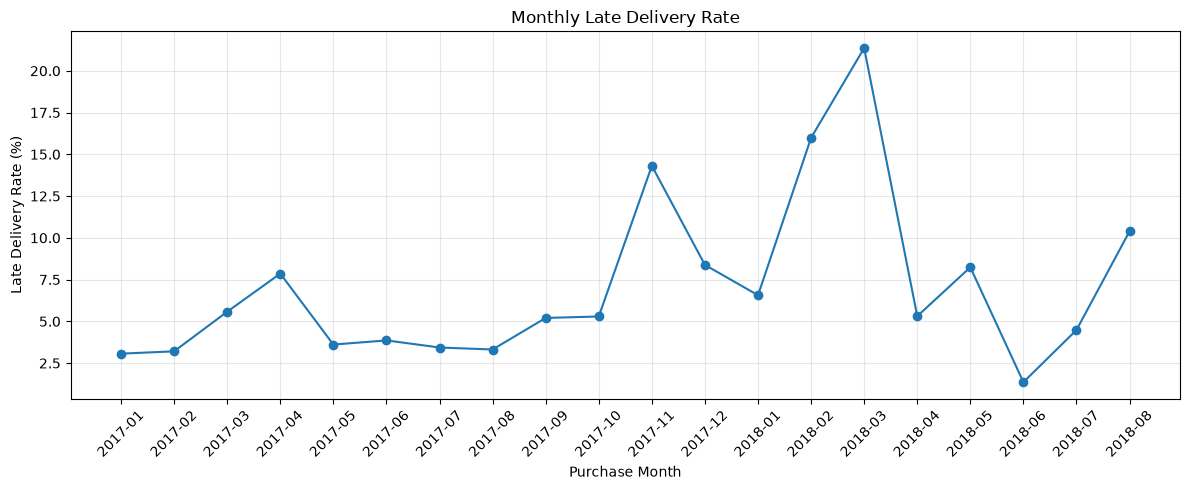

In [1413]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_trend.index.astype(str),
    monthly_trend["late_rate"],
    marker="o"
)

plt.title("Monthly Late Delivery Rate")
plt.xlabel("Purchase Month")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 15.6 Delivery Performance by Customer State

Overall delivery performance can hide geographic differences.
State-level analysis is therefore used to identify whether certain
customer regions experience higher late-delivery rates than others.

Only delivered orders with a valid customer delivery date are included.

In [1414]:
# Add customer state to delivered orders

delivered_orders_geo = delivered_orders.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left",
    validate="one_to_one"
)

delivered_orders_geo.shape

(96478, 15)

In [1415]:
state_delivery = (
    delivered_orders_geo[
        delivered_orders_geo["delivery_delay_days"].notna()
    ]
    .groupby("customer_state")
    .agg(
        delivered_orders=("order_id", "count"),
        late_orders=(
            "delivery_delay_days",
            lambda x: (x > 0).sum()
        ),
        avg_delay_days=("delivery_delay_days", "mean"),
        median_delay_days=("delivery_delay_days", "median")
    )
)

state_delivery["late_rate"] = (
    state_delivery["late_orders"]
    / state_delivery["delivered_orders"]
    * 100
)

state_delivery = state_delivery.sort_values(
    "late_rate",
    ascending=False
)

state_delivery.round(2)

,delivered_orders,late_orders,avg_delay_days,median_delay_days,late_rate
customer_state,,,,,
AL,397,95,-8.03,-9.43,23.93
MA,717,141,-8.89,-10.01,19.67
PI,476,76,-10.63,-13.08,15.97
CE,1279,196,-10.11,-12.27,15.32
SE,335,51,-9.33,-12.13,15.22
BA,3256,457,-10.10,-11.56,14.04
RJ,12350,1664,-11.05,-12.26,13.47
TO,274,35,-11.44,-12.62,12.77
PA,946,117,-13.39,-15.08,12.37


In [1416]:
state_delivery_reliable = state_delivery[
    state_delivery["delivered_orders"] >= 500
].copy()

state_delivery_reliable.round(2)

,delivered_orders,late_orders,avg_delay_days,median_delay_days,late_rate
customer_state,,,,,
MA,717,141,-8.89,-10.01,19.67
CE,1279,196,-10.11,-12.27,15.32
BA,3256,457,-10.10,-11.56,14.04
RJ,12350,1664,-11.05,-12.26,13.47
PA,946,117,-13.39,-15.08,12.37
ES,1995,244,-9.80,-11.15,12.23
MS,701,81,-10.36,-11.44,11.55
PB,517,57,-12.60,-13.36,11.03
PE,1593,172,-12.61,-13.58,10.80


In [1417]:
state_delivery_reliable.head(10)

,delivered_orders,late_orders,avg_delay_days,median_delay_days,late_rate
customer_state,,,,,
MA,717,141,-8.887844,-10.007199,19.665272
CE,1279,196,-10.110007,-12.273970,15.324472
BA,3256,457,-10.099073,-11.563426,14.035627
RJ,12350,1664,-11.054735,-12.255174,13.473684
PA,946,117,-13.386288,-15.079080,12.367865
ES,1995,244,-9.797109,-11.153183,12.230576
MS,701,81,-10.355558,-11.437535,11.554922
PB,517,57,-12.599502,-13.358229,11.025145
PE,1593,172,-12.607918,-13.584977,10.797238


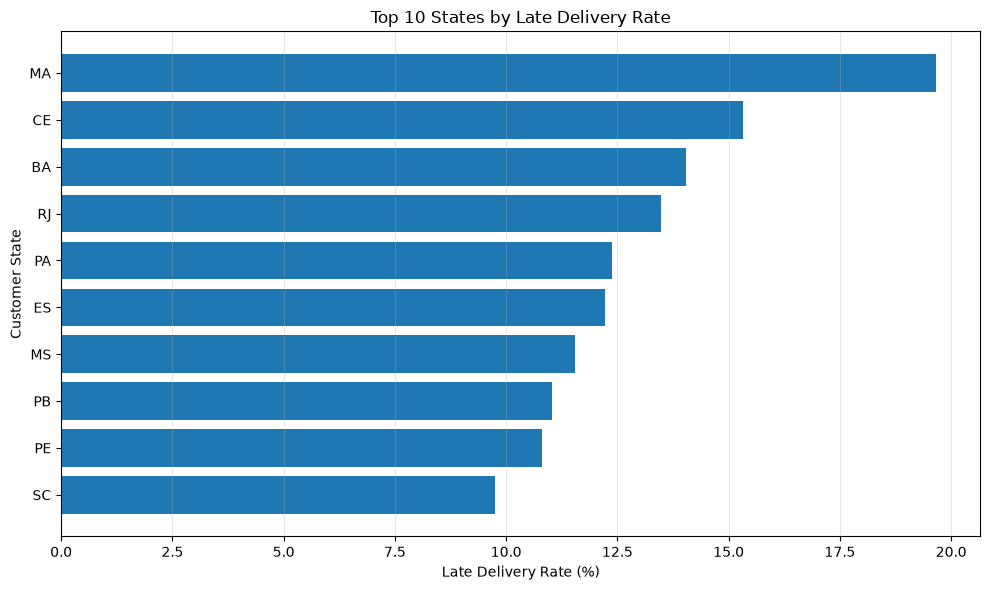

In [1418]:
import matplotlib.pyplot as plt

top_states = state_delivery_reliable.head(10).sort_values(
    "late_rate"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_states.index,
    top_states["late_rate"]
)

plt.title("Top 10 States by Late Delivery Rate")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Customer State")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 15.7 State-Level Delivery Performance

State-level analysis reveals substantial geographic variation in
late-delivery rates. Some states have considerably higher late
delivery rates than the overall platform average.

This suggests that delivery performance may be influenced by
regional logistics conditions, seller distribution, transportation
networks, or geographic distance.

States with sufficient order volume are considered to avoid
misleading results from very small samples.

### 15.8 Key Insight — Geographic Delivery Performance

State-level analysis reveals significant variation in delivery
performance across Brazil.

Maranhao (MA) has the highest late-delivery rate among states with
at least 500 delivered orders, at approximately 19.67%, followed by
Ceara (CE) and Bahia (BA).

These rates are substantially higher than the overall late-delivery
rate of approximately 8.12%.

This indicates that delivery performance is geographically uneven
and suggests that regional logistics, transportation infrastructure,
seller distribution, or geographic distance may influence delivery
reliability.

Further analysis will investigate whether these differences are
associated with seller concentration, product categories, order
volume, or other operational factors.

## 15.9 Seller-Level Delivery Performance

State-level analysis identified geographic differences in delivery
performance.

The next step is to investigate seller-level performance to determine
whether delivery delays are concentrated among specific sellers.

Seller-level analysis can help identify operational outliers and
potential areas for logistics or seller-performance improvement.

In [1419]:
order_seller_map = (
    order_items[
        ["order_id", "seller_id"]
    ]
    .drop_duplicates()
)

order_seller_map.shape

(100010, 2)

In [1420]:
delivered_orders_seller = delivered_orders.merge(
    order_seller_map,
    on="order_id",
    how="left",
    validate="one_to_many"
)

delivered_orders_seller.shape

(97819, 15)

In [1421]:
delivered_orders_seller["seller_id"].isnull().sum()

np.int64(0)

In [1422]:
seller_delivery = (
    delivered_orders_seller[
        delivered_orders_seller["delivery_delay_days"].notna()
    ]
    .groupby("seller_id")
    .agg(
        delivered_orders=("order_id", "count"),
        late_orders=(
            "delivery_delay_days",
            lambda x: (x > 0).sum()
        ),
        avg_delay_days=("delivery_delay_days", "mean"),
        median_delay_days=("delivery_delay_days", "median")
    )
)

seller_delivery["late_rate"] = (
    seller_delivery["late_orders"]
    / seller_delivery["delivered_orders"]
    * 100
)

seller_delivery = seller_delivery.sort_values(
    "late_rate",
    ascending=False
)

seller_delivery.round(2)

,delivered_orders,late_orders,avg_delay_days,median_delay_days,late_rate
seller_id,,,,,
f524ad65d7e0f1daab730ef2d2e86196,1,1,3.84,3.84,100.0
51a04a8a6bdcb23deccc82b0b80742cf,1,1,7.82,7.82,100.0
f5fea3ffed6c2e889bab72705557c63a,1,1,1.70,1.70,100.0
391bbd13b6452244774beff1824006ed,1,1,24.03,24.03,100.0
19484c79cef6c062cb177aa4ef2fcc3c,1,1,3.50,3.50,100.0
...,...,...,...,...,...
3d4b1ae7539303b5704493798893e82c,6,0,-10.31,-10.18,0.0
ffff564a4f9085cd26170f4732393726,8,0,-47.55,-47.93,0.0
3d621842b2ed28e2b474132480edac3c,8,0,-11.14,-10.85,0.0


In [1423]:
seller_delivery_reliable = seller_delivery[
    seller_delivery["delivered_orders"] >= 50
].copy()

seller_delivery_reliable = seller_delivery_reliable.sort_values(
    "late_rate",
    ascending=False
)

seller_delivery_reliable.round(2)

,delivered_orders,late_orders,avg_delay_days,median_delay_days,late_rate
seller_id,,,,,
54965bbe3e4f07ae045b90b0b8541f52,73,22,-2.87,-8.19,30.14
a49928bcdf77c55c6d6e05e09a9b4ca5,96,25,-3.68,-6.13,26.04
beadbee30901a7f61d031b6b686095ad,64,16,-8.75,-8.07,25.00
06a2c3af7b3aee5d69171b0e14f0ee87,389,90,-10.66,-11.33,23.14
cac4c8e7b1ca6252d8f20b2fc1a2e4af,74,17,-6.08,-9.67,22.97
...,...,...,...,...,...
cc63f0dd2acba93ffed4fe9f8e0321fa,55,0,-11.14,-8.30,0.00
e882b2a25a10b9c057cc49695f222c19,57,0,-18.46,-19.21,0.00
f3b80352b986ab4d1057a4b724be19d0,86,0,-12.43,-12.60,0.00


In [1424]:
seller_delivery_reliable.head(10)

,delivered_orders,late_orders,avg_delay_days,median_delay_days,late_rate
seller_id,,,,,
54965bbe3e4f07ae045b90b0b8541f52,73,22,-2.874650,-8.185417,30.136986
a49928bcdf77c55c6d6e05e09a9b4ca5,96,25,-3.678302,-6.128148,26.041667
beadbee30901a7f61d031b6b686095ad,64,16,-8.751648,-8.070932,25.000000
06a2c3af7b3aee5d69171b0e14f0ee87,389,90,-10.657200,-11.331435,23.136247
cac4c8e7b1ca6252d8f20b2fc1a2e4af,74,17,-6.078219,-9.667413,22.972973
6039e27294dc75811c0d8a39069f52c0,63,14,-6.620415,-8.432581,22.222222
1ca7077d890b907f89be8c954a02686a,108,24,-5.961806,-5.738206,22.222222
712e6ed8aa4aa1fa65dab41fed5737e4,77,17,-8.419706,-14.119919,22.077922
ea566164622c6b439516ab18062c42cd,50,11,-7.391326,-8.071742,22.000000


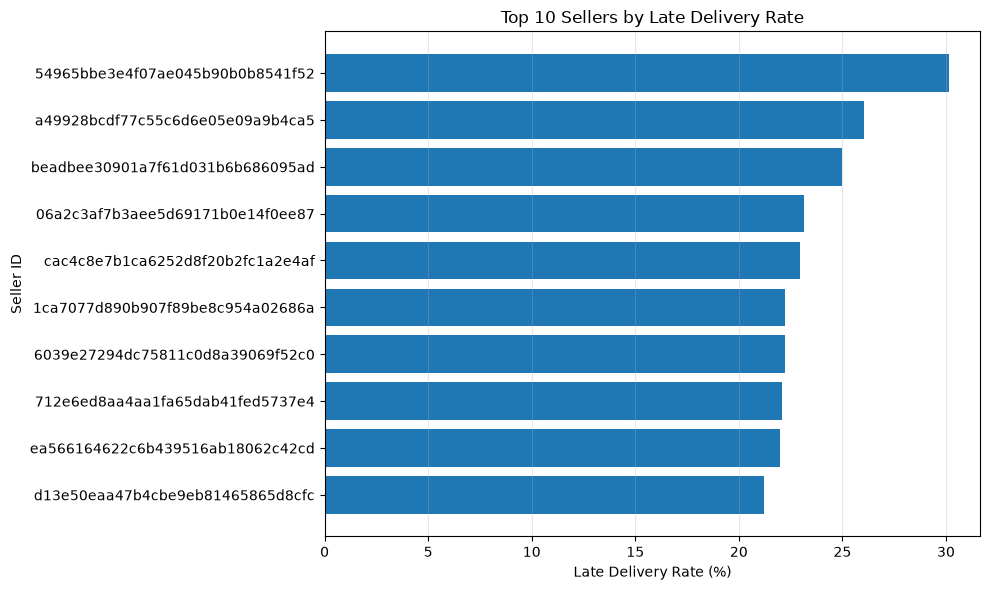

In [1425]:
top_sellers = seller_delivery_reliable.head(10).sort_values(
    "late_rate"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_sellers.index,
    top_sellers["late_rate"]
)

plt.title("Top 10 Sellers by Late Delivery Rate")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Seller ID")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 15.10 Key Insight — Seller-Level Delivery Performance

Seller-level analysis reveals substantial variation in delivery
performance.

Among sellers with at least 50 delivered orders, several sellers
show late-delivery rates above 20%, significantly exceeding the
overall platform late-delivery rate.

This suggests that delivery delays may be concentrated among
specific sellers rather than being purely a platform-wide logistics
problem.

High-volume sellers with consistently high late-delivery rates
represent important candidates for further investigation.

Potential factors include seller location, product category,
order volume, and shipping practices.

## 15.11 Product Category Delivery Performance

Seller-level analysis showed that delivery performance varies
substantially across sellers.

The next step is to determine whether certain product categories
also experience higher delivery delays.

Category-level analysis can help identify whether delays are
associated with the type of products being shipped, in addition
to seller and geographic factors.

In [1426]:
order_items_orders = order_items.merge(
    order_delivery_metrics[
        [__
            "order_id",
            "order_status",
            "order_purchase_timestamp",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
            "delivery_delay_days"
        ]
    ],
    on="order_id",
    how="left",
    validate="many_to_one"
)

order_items_orders.shape

SyntaxError: invalid syntax (1422608693.py, line 4)

In [ ]:
order_delivery_metrics = orders.copy()

order_delivery_metrics["delivery_delay_days"] = (
    order_delivery_metrics["order_delivered_customer_date"]
    - order_delivery_metrics["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

order_delivery_metrics[
    ["order_id", "order_status", "delivery_delay_days"]
].head()

,order_id,order_status,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,-7.107488
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,-5.355729
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,-17.245498
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,-12.980069
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,-9.238171


In [ ]:
items_with_products = order_items_orders.merge(
    products_enriched[
        [
            "product_id",
            "product_category_name",
            "product_category_name_english"
        ]
    ],
    on="product_id",
    how="left",
    validate="many_to_one"
)

items_with_products.shape

(112650, 14)

In [ ]:
items_with_products[
    "product_category_name_english"
].isnull().sum()

np.int64(1627)

In [ ]:
# sirf delivered orders
delivered_items = items_with_products[
    items_with_products["order_status"] == "delivered"
].copy()

delivered_items.shape

(110197, 14)

In [ ]:
# catrgory performance
category_delivery = (
    delivered_items[
        delivered_items["delivery_delay_days"].notna()
    ]
    .groupby("product_category_name_english")
    .agg(
        delivered_items=("order_id", "count"),
        late_items=(
            "delivery_delay_days",
            lambda x: (x > 0).sum()
        ),
        avg_delay_days=("delivery_delay_days", "mean"),
        median_delay_days=("delivery_delay_days", "median")
    )
)

category_delivery["late_rate"] = (
    category_delivery["late_items"]
    / category_delivery["delivered_items"]
    * 100
)

category_delivery = category_delivery.sort_values(
    "late_rate",
    ascending=False
)

category_delivery.round(2)

,delivered_items,late_items,avg_delay_days,median_delay_days,late_rate
product_category_name_english,,,,,
home_comfort_2,30,5,-7.79,-11.59,16.67
furniture_mattress_and_upholstery,37,5,-6.48,-9.21,13.51
audio,362,46,-9.47,-10.23,12.71
fashion_underwear_beach,127,16,-10.21,-11.31,12.60
christmas_supplies,150,18,-11.33,-12.22,12.00
...,...,...,...,...,...
diapers_and_hygiene,37,1,-10.66,-11.32,2.70
fashion_childrens_clothes,7,0,-14.99,-17.08,0.00
cds_dvds_musicals,14,0,-16.10,-15.64,0.00


In [ ]:
# select category with min 100 delivered items 
category_delivery_reliable = category_delivery[
    category_delivery["delivered_items"] >= 100
].copy()

category_delivery_reliable = category_delivery_reliable.sort_values(
    "late_rate",
    ascending=False
)

category_delivery_reliable.round(2)

,delivered_items,late_items,avg_delay_days,median_delay_days,late_rate
product_category_name_english,,,,,
audio,362,46,-9.47,-10.23,12.71
fashion_underwear_beach,127,16,-10.21,-11.31,12.60
christmas_supplies,150,18,-11.33,-12.22,12.00
books_technical,263,29,-10.60,-11.18,11.03
home_confort,429,44,-9.11,-10.24,10.26
construction_tools_lights,301,30,-10.51,-11.00,9.97
food,499,49,-9.18,-9.16,9.82
electronics,2729,266,-10.43,-11.17,9.75
health_beauty,9465,857,-11.27,-12.04,9.05


In [ ]:
category_delivery_reliable.head(15)

,delivered_items,late_items,avg_delay_days,median_delay_days,late_rate
product_category_name_english,,,,,
audio,362,46,-9.466330,-10.232060,12.707182
fashion_underwear_beach,127,16,-10.210535,-11.307465,12.598425
christmas_supplies,150,18,-11.328950,-12.223218,12.000000
books_technical,263,29,-10.601557,-11.184664,11.026616
home_confort,429,44,-9.114846,-10.237859,10.256410
construction_tools_lights,301,30,-10.507701,-11.003669,9.966777
food,499,49,-9.179071,-9.162014,9.819639
electronics,2729,266,-10.434594,-11.168194,9.747160
health_beauty,9465,857,-11.267750,-12.038461,9.054411


## what we are looking for 
Delivery Performance
│
├── Time
│   └── Monthly
│
├── Geography
│   └── State
│
├── Seller
│   └── Seller-level
│
└── Product
    └── Category ← ABHI

### 15.12 Key Insight — Product Category Delivery Performance

Category-level analysis shows that delivery performance varies across
product categories.

Among categories with at least 100 delivered items, several categories
have late-delivery rates above the overall platform average of
approximately 8.12%.

Fashion, music/audio, books, and home-related categories appear among
the higher late-delivery categories.

However, category-level differences alone do not establish causation.
The observed variation may also be influenced by seller distribution,
geography, product characteristics, and order volume.

Further analysis will combine category, seller, and geographic
information to identify potential operational drivers of delivery
delays.

## 15.13 Revenue Performance by Product Category

Delivery rate alone does not indicate business importance.

A category with a high late-delivery rate may have very low sales,
while another category with a slightly lower late-delivery rate may
generate substantially more revenue.

Therefore, we will analyze product sales value alongside delivery
performance to identify categories that are both commercially
important and operationally problematic.

Product price is treated as product sales value, while freight is
analyzed separately.

In [ ]:
category_sales = (
    order_items
    .groupby("product_id")
    .agg(
        total_sales=("price", "sum"),
        total_freight=("freight_value", "sum"),
        items_sold=("order_id", "count")
    )
)

category_sales = category_sales.reset_index()

category_sales = category_sales.merge(
    products_enriched[
        [
            "product_id",
            "product_category_name",
            "product_category_name_english"
        ]
    ],
    on="product_id",
    how="left",
    validate="one_to_one"
)

category_sales.head()

,product_id,total_sales,total_freight,items_sold,product_category_name,product_category_name_english
0,00066f42aeeb9f3007548bb9d3f33c38,101.65,18.59,1,perfumaria,perfumery
1,00088930e925c41fd95ebfe695fd2655,129.90,13.93,1,automotivo,auto
2,0009406fd7479715e4bef61dd91f2462,229.00,13.10,1,cama_mesa_banho,bed_bath_table
3,000b8f95fcb9e0096488278317764d19,117.80,39.20,2,utilidades_domesticas,housewares
4,000d9be29b5207b54e86aa1b1ac54872,199.00,19.27,1,relogios_presentes,watches_gifts


In [ ]:
category_revenue = (
    category_sales
    .groupby("product_category_name_english")
    .agg(
        total_sales=("total_sales", "sum"),
        total_freight=("total_freight", "sum"),
        items_sold=("items_sold", "sum")
    )
    .sort_values("total_sales", ascending=False)
)

category_revenue["sales_share_pct"] = (
    category_revenue["total_sales"]
    / category_revenue["total_sales"].sum()
    * 100
)

category_revenue.round(2)

,total_sales,total_freight,items_sold,sales_share_pct
product_category_name_english,,,,
health_beauty,1258681.34,182566.73,9670,9.39
watches_gifts,1205005.68,100535.93,5991,8.99
bed_bath_table,1036988.68,204693.04,11115,7.73
sports_leisure,988048.97,168607.51,8641,7.37
computers_accessories,911954.32,147318.08,7827,6.80
...,...,...,...,...
flowers,1110.04,488.87,33,0.01
home_comfort_2,760.27,410.31,30,0.01
cds_dvds_musicals,730.00,224.99,14,0.01


In [ ]:
category_revenue.head(15).round(2)

,total_sales,total_freight,items_sold,sales_share_pct
product_category_name_english,,,,
health_beauty,1258681.34,182566.73,9670,9.39
watches_gifts,1205005.68,100535.93,5991,8.99
bed_bath_table,1036988.68,204693.04,11115,7.73
sports_leisure,988048.97,168607.51,8641,7.37
computers_accessories,911954.32,147318.08,7827,6.80
furniture_decor,729762.49,172749.30,8334,5.44
cool_stuff,635290.85,84039.10,3796,4.74
housewares,632248.66,146149.11,6964,4.72
auto,592720.11,92664.21,4235,4.42


In [ ]:
category_revenue["avg_item_price"] = (
    category_revenue["total_sales"]
    / category_revenue["items_sold"]
)

category_revenue.sort_values(
    "total_sales",
    ascending=False
).head(15).round(2)

,total_sales,total_freight,items_sold,sales_share_pct,avg_item_price
product_category_name_english,,,,,
health_beauty,1258681.34,182566.73,9670,9.39,130.16
watches_gifts,1205005.68,100535.93,5991,8.99,201.14
bed_bath_table,1036988.68,204693.04,11115,7.73,93.30
sports_leisure,988048.97,168607.51,8641,7.37,114.34
computers_accessories,911954.32,147318.08,7827,6.80,116.51
furniture_decor,729762.49,172749.30,8334,5.44,87.56
cool_stuff,635290.85,84039.10,3796,4.74,167.36
housewares,632248.66,146149.11,6964,4.72,90.79
auto,592720.11,92664.21,4235,4.42,139.96


In [ ]:
# Revenue + Delivery Performance Combine
category_delivery_reliable_reset = category_delivery_reliable.reset_index()

category_business_performance = category_revenue.merge(
    category_delivery_reliable_reset[
        [
            "product_category_name_english",
            "delivered_items",
            "late_items",
            "avg_delay_days",
            "median_delay_days",
            "late_rate"
        ]
    ],
    on="product_category_name_english",
    how="left",
    validate="one_to_one"
)

category_business_performance.head(15).round(2)

,product_category_name_english,total_sales,total_freight,items_sold,sales_share_pct,avg_item_price,delivered_items,late_items,avg_delay_days,median_delay_days,late_rate
0,health_beauty,1258681.34,182566.73,9670,9.39,130.16,9465.0,857.0,-11.27,-12.04,9.05
1,watches_gifts,1205005.68,100535.93,5991,8.99,201.14,5857.0,485.0,-11.21,-12.12,8.28
2,bed_bath_table,1036988.68,204693.04,11115,7.73,93.30,10953.0,920.0,-10.96,-11.41,8.40
3,sports_leisure,988048.97,168607.51,8641,7.37,114.34,8430.0,625.0,-11.31,-12.10,7.41
4,computers_accessories,911954.32,147318.08,7827,6.80,116.51,7643.0,594.0,-11.73,-12.31,7.77
5,furniture_decor,729762.49,172749.30,8334,5.44,87.56,8160.0,688.0,-11.71,-11.97,8.43
6,cool_stuff,635290.85,84039.10,3796,4.74,167.36,3718.0,251.0,-11.80,-12.24,6.75
7,housewares,632248.66,146149.11,6964,4.72,90.79,6795.0,441.0,-11.61,-12.04,6.49
8,auto,592720.11,92664.21,4235,4.42,139.96,4139.0,343.0,-10.74,-11.41,8.29
9,garden_tools,485256.46,98962.75,4347,3.62,111.63,4268.0,340.0,-11.28,-12.22,7.97


In [ ]:
category_business_performance = category_business_performance.sort_values(
    "total_sales",
    ascending=False
)

category_business_performance.head(15).round(2)

,product_category_name_english,total_sales,total_freight,items_sold,sales_share_pct,avg_item_price,delivered_items,late_items,avg_delay_days,median_delay_days,late_rate
0,health_beauty,1258681.34,182566.73,9670,9.39,130.16,9465.0,857.0,-11.27,-12.04,9.05
1,watches_gifts,1205005.68,100535.93,5991,8.99,201.14,5857.0,485.0,-11.21,-12.12,8.28
2,bed_bath_table,1036988.68,204693.04,11115,7.73,93.30,10953.0,920.0,-10.96,-11.41,8.40
3,sports_leisure,988048.97,168607.51,8641,7.37,114.34,8430.0,625.0,-11.31,-12.10,7.41
4,computers_accessories,911954.32,147318.08,7827,6.80,116.51,7643.0,594.0,-11.73,-12.31,7.77
5,furniture_decor,729762.49,172749.30,8334,5.44,87.56,8160.0,688.0,-11.71,-11.97,8.43
6,cool_stuff,635290.85,84039.10,3796,4.74,167.36,3718.0,251.0,-11.80,-12.24,6.75
7,housewares,632248.66,146149.11,6964,4.72,90.79,6795.0,441.0,-11.61,-12.04,6.49
8,auto,592720.11,92664.21,4235,4.42,139.96,4139.0,343.0,-10.74,-11.41,8.29
9,garden_tools,485256.46,98962.75,4347,3.62,111.63,4268.0,340.0,-11.28,-12.22,7.97


In [ ]:
high_sales_categories = category_business_performance[
    category_business_performance["total_sales"] >= 500000
].copy()

high_sales_categories = high_sales_categories.sort_values(
    "late_rate",
    ascending=False
)

high_sales_categories.round(2)

,product_category_name_english,total_sales,total_freight,items_sold,sales_share_pct,avg_item_price,delivered_items,late_items,avg_delay_days,median_delay_days,late_rate
0,health_beauty,1258681.34,182566.73,9670,9.39,130.16,9465.0,857.0,-11.27,-12.04,9.05
5,furniture_decor,729762.49,172749.30,8334,5.44,87.56,8160.0,688.0,-11.71,-11.97,8.43
2,bed_bath_table,1036988.68,204693.04,11115,7.73,93.30,10953.0,920.0,-10.96,-11.41,8.40
8,auto,592720.11,92664.21,4235,4.42,139.96,4139.0,343.0,-10.74,-11.41,8.29
1,watches_gifts,1205005.68,100535.93,5991,8.99,201.14,5857.0,485.0,-11.21,-12.12,8.28
4,computers_accessories,911954.32,147318.08,7827,6.80,116.51,7643.0,594.0,-11.73,-12.31,7.77
3,sports_leisure,988048.97,168607.51,8641,7.37,114.34,8430.0,625.0,-11.31,-12.10,7.41
6,cool_stuff,635290.85,84039.10,3796,4.74,167.36,3718.0,251.0,-11.80,-12.24,6.75
7,housewares,632248.66,146149.11,6964,4.72,90.79,6795.0,441.0,-11.61,-12.04,6.49


In [ ]:
high_sales_categories[
    [
        "product_category_name_english",
        "total_sales",
        "sales_share_pct",
        "items_sold",
        "late_rate",
        "late_items"
    ]
].round(2)

,product_category_name_english,total_sales,sales_share_pct,items_sold,late_rate,late_items
0,health_beauty,1258681.34,9.39,9670,9.05,857.0
5,furniture_decor,729762.49,5.44,8334,8.43,688.0
2,bed_bath_table,1036988.68,7.73,11115,8.40,920.0
8,auto,592720.11,4.42,4235,8.29,343.0
1,watches_gifts,1205005.68,8.99,5991,8.28,485.0
4,computers_accessories,911954.32,6.80,7827,7.77,594.0
3,sports_leisure,988048.97,7.37,8641,7.41,625.0
6,cool_stuff,635290.85,4.74,3796,6.75,251.0
7,housewares,632248.66,4.72,6964,6.49,441.0


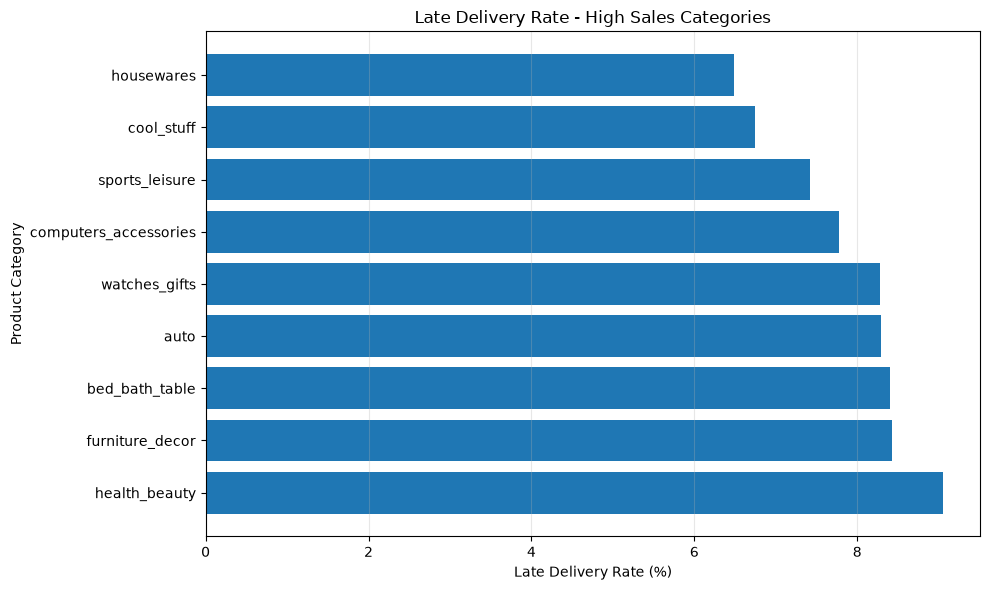

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    high_sales_categories["product_category_name_english"],
    high_sales_categories["late_rate"]
)

plt.title("Late Delivery Rate - High Sales Categories")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Product Category")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 15.7 Business Insight — High-Sales Categories and Delivery Performance

High-sales product categories were compared with their late-delivery rates to identify categories that are both commercially important and operationally challenging.

The analysis shows that **health_beauty** has the highest late-delivery rate among the high-sales categories at approximately **9.05%**, while also generating the highest total sales of approximately **1.26 million**.

Other important categories with relatively high late-delivery rates include **furniture_decor (8.43%)**, **bed_bath_table (8.40%)**, **auto (8.29%)**, and **watches_gifts (8.28%)**.

This suggests that delivery performance should not be evaluated independently of business importance. High-revenue categories with elevated late-delivery rates should be prioritized for operational investigation.

Further analysis can examine whether these delays are driven by specific sellers, geographic regions, or product characteristics.

In [ ]:
# Seller performance ko business perspective se dekhenge
# Hum sirf late rate nahi dekhenge. Pehle high-volume sellers filter karenge, taaki 2-3 orders wale sellers ki wajah se misleading result na aaye.

seller_business_performance = seller_delivery_reliable.reset_index()

seller_business_performance = seller_business_performance[
    seller_business_performance["delivered_orders"] >= 100
].copy()

seller_business_performance = seller_business_performance.sort_values(
    "late_rate",
    ascending=False
)

seller_business_performance.head(15).round(2)

,seller_id,delivered_orders,late_orders,avg_delay_days,median_delay_days,late_rate
3,06a2c3af7b3aee5d69171b0e14f0ee87,389,90,-10.66,-11.33,23.14
6,1ca7077d890b907f89be8c954a02686a,108,24,-5.96,-5.74,22.22
11,88460e8ebdecbfecb5f9601833981930,246,48,-10.51,-12.00,19.51
12,e5a3438891c0bfdb9394643f95273d8e,216,40,-5.83,-7.67,18.52
13,cd68562d3f44870c08922d380acae552,122,22,-7.47,-10.19,18.03
20,8160255418d5aaa7dbdc9f4c64ebda44,380,63,-7.42,-8.75,16.58
22,2c9e548be18521d1c43cde1c582c6de8,124,20,-5.93,-7.29,16.13
29,dd7ddc04e1b6c2c614352b383efe2d36,121,19,-7.14,-7.22,15.70
31,f7ba60f8c3f99e7ee4042fdef03b70c4,218,34,-8.35,-9.26,15.60
32,431af27f296bc6519d890aa5a05fdb11,116,18,-6.53,-8.15,15.52


In [ ]:
seller_business_performance[
    [
        "seller_id",
        "delivered_orders",
        "late_orders",
        "late_rate",
        "avg_delay_days",
        "median_delay_days"
    ]
].head(15).round(2)

,seller_id,delivered_orders,late_orders,late_rate,avg_delay_days,median_delay_days
3,06a2c3af7b3aee5d69171b0e14f0ee87,389,90,23.14,-10.66,-11.33
6,1ca7077d890b907f89be8c954a02686a,108,24,22.22,-5.96,-5.74
11,88460e8ebdecbfecb5f9601833981930,246,48,19.51,-10.51,-12.00
12,e5a3438891c0bfdb9394643f95273d8e,216,40,18.52,-5.83,-7.67
13,cd68562d3f44870c08922d380acae552,122,22,18.03,-7.47,-10.19
20,8160255418d5aaa7dbdc9f4c64ebda44,380,63,16.58,-7.42,-8.75
22,2c9e548be18521d1c43cde1c582c6de8,124,20,16.13,-5.93,-7.29
29,dd7ddc04e1b6c2c614352b383efe2d36,121,19,15.70,-7.14,-7.22
31,f7ba60f8c3f99e7ee4042fdef03b70c4,218,34,15.60,-8.35,-9.26
32,431af27f296bc6519d890aa5a05fdb11,116,18,15.52,-6.53,-8.15


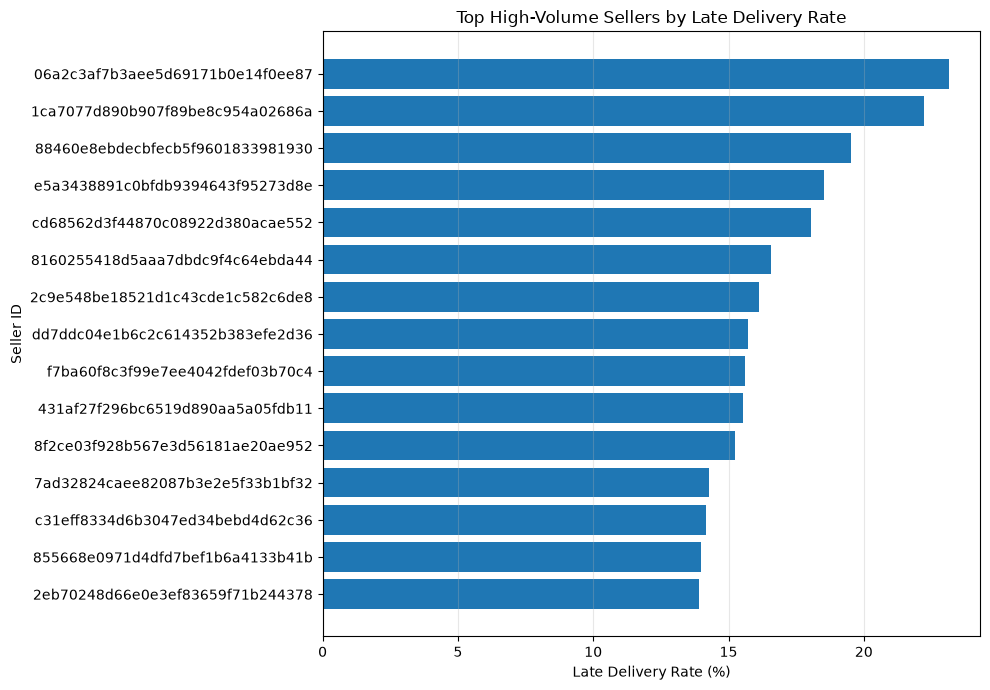

In [ ]:
top_seller_delay = seller_business_performance.head(15).sort_values(
    "late_rate"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_seller_delay["seller_id"],
    top_seller_delay["late_rate"]
)

plt.title("Top High-Volume Sellers by Late Delivery Rate")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Seller ID")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 16.2 Business Insight — Seller Delivery Performance

Seller-level analysis was performed after restricting the analysis to sellers with at least 100 delivered orders, reducing the influence of very small sellers.

The results show substantial variation in delivery performance across high-volume sellers. Several sellers have late-delivery rates above 15%, while the highest observed seller has a late-delivery rate of approximately 23%.

This indicates that delivery performance is not uniform across sellers and that a subset of high-volume sellers may be contributing disproportionately to late deliveries.

These sellers should be prioritized for further investigation, particularly with respect to shipping timelines, geographic coverage, product categories handled, and operational capacity.

Seller-level performance can therefore be used as an important dimension for identifying potential operational bottlenecks.

# Ab tak humne kya cover kiya

01_data_understanding.ipynb mein ab humne:

Dataset structure & quality
Orders & delivery performance
On-time vs late delivery
Monthly delivery trends
Yearly delivery trends
State-level delivery performance
Product-category delivery performance
Category revenue + delivery performance
High-sales/high-delay categories
Seller-level delivery performance

cover kar liya hai.
Next major analysis: hum Order Value / Revenue + Delivery Performance ko investigate karenge — basically dekhेंगे ki expensive/high-value orders mein delivery delay ka pattern different hai ya nahi.

In [1427]:
# Har order ki total value calculate karna 
order_value = (
    order_items
    .groupby("order_id")
    .agg(
        item_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
)

order_value["total_order_value"] = (
    order_value["item_value"] +
    order_value["freight_value"]
)

order_value.head(10).round(2)

,item_value,freight_value,total_order_value
order_id,,,
00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04
00048cc3ae777c65dbb7d2a0634bc1ea,21.90,12.69,34.59
00054e8431b9d7675808bcb819fb4a32,19.90,11.85,31.75
000576fe39319847cbb9d288c5617fa6,810.00,70.75,880.75
0005a1a1728c9d785b8e2b08b904576c,145.95,11.65,157.60


In [1428]:
order_value["total_order_value"].describe().round(2)

count    98666.00
mean       160.58
std        220.47
min          9.59
25%         61.98
50%        105.29
75%        176.87
max      13664.08
Name: total_order_value, dtype: float64

In [1429]:
# Delivery information ke saath combine
order_value_delivery = order_value.merge(
    orders[
        [
            "order_id",
            "order_status",
            "delivery_time_days",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]
    ],
    on="order_id",
    how="left",
    validate="one_to_one"
)

order_value_delivery.shape

(98666, 8)

In [1430]:
# Sirf delivered orders
delivered_order_value = order_value_delivery[
    order_value_delivery["order_status"] == "delivered"
].copy()

delivered_order_value.shape

(96478, 8)

In [ ]:
# order value bucket
delivered_order_value["order_value_bucket"] = pd.qcut(
    delivered_order_value["total_order_value"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

delivered_order_value["order_value_bucket"].value_counts().sort_index()

#Isse orders ko 4 equal-sized groups (quartiles) mein divide karenge.

order_value_bucket
Low          24126
Medium       24173
High         24060
Very High    24119
Name: count, dtype: int64

In [1432]:
delivered_order_value.groupby("order_value_bucket")[
    "total_order_value"
].agg(
    count="count",
    avg_value="mean",
    median_value="median"
).round(2)

,count,avg_value,median_value
order_value_bucket,,,
Low,24126,42.92,43.26
Medium,24173,81.67,80.65
High,24060,137.09,135.59
Very High,24119,377.79,264.16


In [1435]:
delivered_order_value["is_late"] = (
    delivered_order_value["order_delivered_customer_date"]
    > delivered_order_value["order_estimated_delivery_date"]
)

delivered_order_value["is_late"].value_counts()

is_late
False    88652
True      7826
Name: count, dtype: int64

In [1437]:
value_delivery = (
    delivered_order_value
    .groupby("order_value_bucket", observed=True)
    .agg(
        delivered_orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        avg_delivery_days=("delivery_time_days", "mean"),
        median_delivery_days=("delivery_time_days", "median")
    )
)

value_delivery["late_rate"] = (
    value_delivery["late_orders"]
    / value_delivery["delivered_orders"]
    * 100
)

value_delivery.round(2)

,delivered_orders,late_orders,avg_delivery_days,median_delivery_days,late_rate
order_value_bucket,,,,,
Low,24126,1733,10.92,8.87,7.18
Medium,24173,1925,12.47,10.18,7.96
High,24060,2005,12.92,10.77,8.33
Very High,24119,2163,13.93,11.33,8.97


In [1438]:
value_delivery.sort_values(
    "late_rate",
    ascending=False
).round(2)

,delivered_orders,late_orders,avg_delivery_days,median_delivery_days,late_rate
order_value_bucket,,,,,
Very High,24119,2163,13.93,11.33,8.97
High,24060,2005,12.92,10.77,8.33
Medium,24173,1925,12.47,10.18,7.96
Low,24126,1733,10.92,8.87,7.18


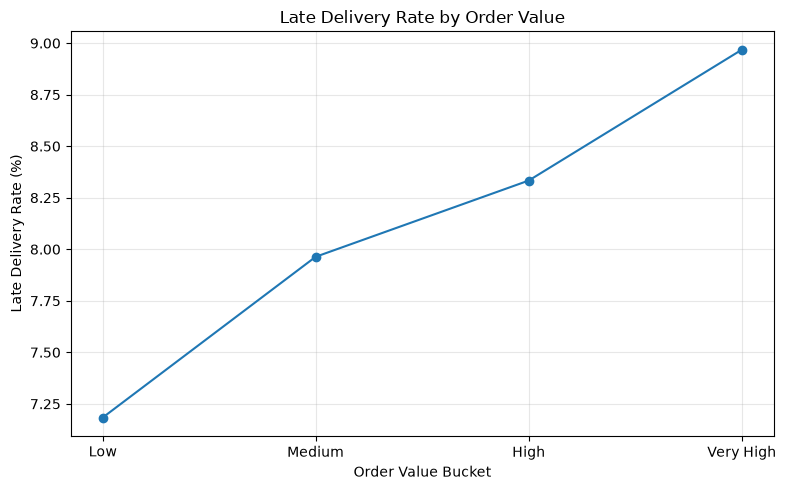

In [1439]:
plt.figure(figsize=(8, 5))

plt.plot(
    value_delivery.index.astype(str),
    value_delivery["late_rate"],
    marker="o"
)

plt.title("Late Delivery Rate by Order Value")
plt.xlabel("Order Value Bucket")
plt.ylabel("Late Delivery Rate (%)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 17.1 Business Insight — Order Value and Delivery Performance

Order value was divided into four quartile-based buckets to investigate whether delivery performance varies with order value.

The analysis shows a gradual increase in late-delivery rates as order value increases. Low-value orders have a late-delivery rate of approximately 7.18%, while very-high-value orders have a late-delivery rate of approximately 8.97%.

Average delivery time also increases from approximately 10.92 days for low-value orders to 13.93 days for very-high-value orders.

This suggests that higher-value orders may require additional operational attention, although the analysis shows an association rather than proving that order value itself causes delivery delays.

In [1440]:
# Customer-level spending calculate karna
customer_behavior = orders_with_customer[
    [
        "order_id",
        "customer_unique_id"
    ]
].merge(
    order_value.reset_index(),
    on="order_id",
    how="left",
    validate="one_to_one"
)

customer_behavior.head()

,order_id,customer_unique_id,item_value,freight_value,total_order_value
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90,8.72,28.62


In [1441]:
# sustomer- level summary
customer_summary = (
    customer_behavior
    .groupby("customer_unique_id")
    .agg(
        order_count=("order_id", "count"),
        total_spend=("total_order_value", "sum"),
        avg_order_value=("total_order_value", "mean")
    )
)

customer_summary.head(10).round(2)

,order_count,total_spend,avg_order_value
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19
0000f46a3911fa3c0805444483337064,1,86.22,86.22
0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62
0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89
0004bd2a26a76fe21f786e4fbd80607f,1,166.98,166.98
00050ab1314c0e55a6ca13cf7181fecf,1,35.38,35.38
00053a61a98854899e70ed204dd4bafe,1,419.18,419.18
0005e1862207bf6ccc02e4228effd9a0,1,150.12,150.12


In [ ]:
# One-time vs Repeat customers
customer_summary["customer_type"] = np.where(
    customer_summary["order_count"] == 1,
    "One-time",
    "Repeat"
)

customer_summary["customer_type"].value_counts()

customer_type
One-time    93099
Repeat       2997
Name: count, dtype: int64

In [1443]:
# Dono customer groups compare karna
customer_type_summary = (
    customer_summary
    .groupby("customer_type")
    .agg(
        customers=("order_count", "count"),
        avg_orders=("order_count", "mean"),
        avg_spend=("total_spend", "mean"),
        median_spend=("total_spend", "median"),
        total_revenue=("total_spend", "sum")
    )
)

customer_type_summary.round(2)

,customers,avg_orders,avg_spend,median_spend,total_revenue
customer_type,,,,,
One-time,93099,1.00,160.28,105.0,14921510.75
Repeat,2997,2.12,307.66,223.1,922042.49


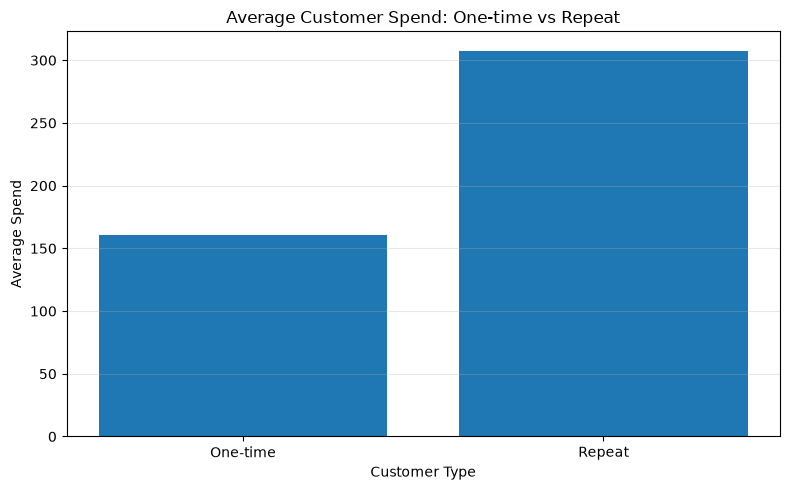

In [1444]:
plt.figure(figsize=(8, 5))

plt.bar(
    customer_type_summary.index,
    customer_type_summary["avg_spend"]
)

plt.title("Average Customer Spend: One-time vs Repeat")
plt.xlabel("Customer Type")
plt.ylabel("Average Spend")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Customer Retention and Spending

Customer-level analysis shows that the majority of customers are one-time buyers, while only a small proportion return for additional purchases.

Repeat customers have a substantially higher average spend than one-time customers, indicating that customer retention is commercially valuable.

This suggests an opportunity to improve repeat purchases through customer retention strategies such as targeted offers, personalized recommendations, loyalty programs, and post-purchase engagement.

Key findings:
- One-time customers: 93,099
- Repeat customers: 2,997
- Average spend of one-time customers: 160.28
- Average spend of repeat customers: 307.66
- Repeat customers spend approximately 1.9× more on average.

# Final EDA Findings

## 1. Customer Behavior
- The dataset contains 99,441 customer records representing 96,096 unique customers.
- Approximately 3.1% of unique customers made more than one purchase.
- Repeat customers have a significantly higher average spend than one-time customers.
- The average spend of repeat customers is approximately 1.9× that of one-time customers.

## 2. Delivery Performance
- Approximately 91.88% of delivered orders arrived on or before the estimated delivery date.
- Approximately 8.12% of delivered orders were late.
- Delivery performance varies considerably across months, states, sellers, and product categories.
- March 2018 recorded a particularly high late-delivery rate of approximately 21.36%.

## 3. Geographic Performance
- Delivery performance differs substantially across customer states.
- Some states show considerably higher late-delivery rates than the overall average.
- Geographic analysis suggests that location is an important factor to investigate further.

## 4. Seller Performance
- Seller-level analysis shows substantial variation in late-delivery rates.
- Some high-volume sellers have considerably higher late-delivery rates than others.
- Seller performance should therefore be considered when investigating operational delays.

## 5. Product Category Performance
- Delivery performance also varies across product categories.
- Among high-sales categories, health_beauty showed a relatively high late-delivery rate.
- This indicates that product category and sales volume may both be useful factors when investigating delivery performance.

## 6. Order Value
- Order values vary considerably across customers and orders.
- Higher-value orders show a gradual increase in late-delivery rate compared with lower-value orders.
- This suggests a possible relationship between order value and delivery performance that can be investigated further.

## Overall Business Takeaway

The EDA indicates that delivery performance is influenced by multiple factors rather than a single cause.

Geography, seller performance, product category, order value, and customer behavior all provide useful dimensions for further analysis.

The most important business opportunities identified are:
1. Improving delivery reliability in high-delay regions.
2. Identifying and addressing underperforming sellers.
3. Investigating categories with both high sales and high late-delivery rates.
4. Increasing customer retention, as repeat customers demonstrate substantially higher average spending.

# Conclusion

The exploratory analysis provided an overall understanding of customers, orders, products, sellers, revenue, and delivery performance.

The analysis identified meaningful differences across time, geography, sellers, product categories, and order values. It also highlighted a strong customer-retention opportunity because repeat customers spend substantially more than one-time customers.

These findings will be used as the foundation for the next stage of the project: data cleaning, preparation, and deeper business analysis.